# **10. Comparando Modelos Benchmark**

## **10.1. Librerías**

In [25]:
import os
import pandas as pd
from scipy import stats
import numpy as np
from scipy.stats import shapiro
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import levene

from itertools import combinations

## **10.2.Cargando los Resultados**

In [26]:
BASE_DIR = "/home/moon/DEEP/PF/PF_DG/MODELOS"
MODELOS  = ["LSTM_CV", "ConvLSTM_CV", "STGNN_CV", "STGRU_CV", "STT_CV"]

# Métricas base (sin prefijo) usadas en spatial_fold_results
METRICS_BASE = ["RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
                "SkillScore", "RMSE_top10", "Pearson_r", "Bias"]

def load_metrics(model_path, model_name):
    all_files = [f for f in os.listdir(model_path) if f.endswith(".csv")]

    # ── Archivo 1: _results.csv (tiene columnas real_* y log_*) ──────────
    results_files = [f for f in all_files
                     if f.lower().endswith("_results.csv")
                     and "spatial" not in f.lower()
                     and "fold" not in f.lower()]

    # ── Archivo 2: _spatial_fold_results.csv (métricas sin prefijo) ──────
    spatial_files = [f for f in all_files
                     if "spatial" in f.lower() and f.lower().endswith(".csv")]

    result = {}

    # Leer _results.csv → filtrar solo real_*
    if results_files:
        fp = os.path.join(model_path, results_files[0])
        df = pd.read_csv(fp)
        meta_cols = [c for c in df.columns if not c.startswith(("real_", "log_"))]
        real_cols = [c for c in df.columns if c.startswith("real_")]
        if real_cols:
            result["global"] = df[meta_cols + real_cols].copy()
            result["global"]["Model"] = model_name
            
        

    # Leer _spatial_fold_results.csv → usar métricas base tal cual
    if spatial_files:
        fp = os.path.join(model_path, spatial_files[0])
        df = pd.read_csv(fp)
        metric_cols  = [c for c in df.columns if c in METRICS_BASE]
        other_cols   = [c for c in df.columns if c not in METRICS_BASE]
        if metric_cols:
            result["spatial"] = df[other_cols + metric_cols].copy()
            result["spatial"]["Model"] = model_name
           

    return result


global_list  = []
spatial_list = []

for model in MODELOS:
    model_path = os.path.join(BASE_DIR, model)

    result = load_metrics(model_path, model)

    if "global" in result:
        global_list.append(result["global"])
    if "spatial" in result:
        spatial_list.append(result["spatial"])

metrics_global_df  = pd.concat(global_list,  ignore_index=True) if global_list  else pd.DataFrame()
metrics_spatial_df = pd.concat(spatial_list, ignore_index=True) if spatial_list else pd.DataFrame()

for df in [metrics_global_df, metrics_spatial_df]:
    if not df.empty and "Model" in df.columns:
        cols = ["Model"] + [c for c in df.columns if c != "Model"]
        df.drop(columns=[c for c in df.columns if c not in cols], inplace=False)

metrics_global_df  = metrics_global_df[["Model"]  + [c for c in metrics_global_df.columns  if c != "Model"]]  if not metrics_global_df.empty  else metrics_global_df
metrics_spatial_df = metrics_spatial_df[["Model"] + [c for c in metrics_spatial_df.columns if c != "Model"]]  if not metrics_spatial_df.empty else metrics_spatial_df

## **10.3. Comparación de métricas**

### **10.3.1. Métricas test_year por modelo**

In [ ]:
real_cols = [c for c in metrics_global_df.columns if c.startswith("real_")]

summary_df = (
    metrics_global_df
    .groupby(["Model", "test_year"])[real_cols]
    .agg(["mean", "std"])
    .round(4)
)

summary_df.columns = [f"{col}_{stat}" for col, stat in summary_df.columns]
summary_df = summary_df.reset_index()

display(summary_df)

,Model,test_year,real_RMSE_mean,real_RMSE_std,real_MAE_mean,real_MAE_std,real_MAPE_mean,real_MAPE_std,real_sMAPE_mean,real_sMAPE_std,...,real_KGE_mean,real_KGE_std,real_SkillScore_mean,real_SkillScore_std,real_RMSE_top10_mean,real_RMSE_top10_std,real_Pearson_r_mean,real_Pearson_r_std,real_Bias_mean,real_Bias_std
0,ConvLSTM_CV,2022,3.4168,0.3865,1.4761,0.1340,26.8545,1.2016,29.1579,1.1329,...,0.3264,0.1111,0.4813,0.0938,10.0348,1.2388,0.8240,0.0175,-1.1562,0.1801
1,ConvLSTM_CV,2023,3.5758,0.4807,1.9437,0.2157,30.3185,0.2956,32.3874,1.3548,...,0.5603,0.2052,0.6060,0.1196,9.7129,1.7903,0.8474,0.0068,-1.3186,0.5161
2,ConvLSTM_CV,2024,6.9161,1.2933,4.3785,0.7710,40.8715,2.4196,47.0800,7.2408,...,0.4372,0.2520,0.4396,0.1626,17.4716,3.8719,0.8244,0.0324,-3.5632,1.5132
3,LSTM_CV,2022,2.5536,0.1083,1.1471,0.0256,23.5691,1.3594,23.4475,0.7011,...,0.6295,0.0305,0.7032,0.0295,7.2839,0.3963,0.8614,0.0151,-0.5527,0.0367
4,LSTM_CV,2023,3.5251,0.2023,1.7012,0.0497,28.2886,0.8444,26.0355,1.3072,...,0.6919,0.1099,0.6553,0.0474,9.5403,1.0663,0.8203,0.0138,-0.5268,0.3976
5,LSTM_CV,2024,5.9420,0.7643,3.3860,0.2499,36.2004,2.8932,29.7023,1.1327,...,0.6284,0.1419,0.6296,0.0793,15.2211,3.6882,0.8157,0.0202,-0.7780,0.9090
6,STGNN_CV,2022,4.0551,0.2484,1.9340,0.1213,46.7965,3.6219,42.2657,2.9525,...,0.1965,0.1166,0.2770,0.1063,11.8903,0.8910,0.6172,0.0754,-0.9916,0.1994
7,STGNN_CV,2023,4.5802,0.0724,2.8289,0.0771,57.6928,2.0218,49.5014,2.3581,...,0.4317,0.0258,0.3393,0.0344,11.7609,0.5049,0.6050,0.0342,-0.8166,0.1950
8,STGNN_CV,2024,8.0442,0.5009,5.1394,0.3757,63.7529,4.4876,50.3124,2.6273,...,0.2176,0.0411,0.2288,0.0349,21.1142,1.3178,0.5848,0.0239,-2.4906,0.3862
9,STGRU_CV,2022,2.7780,0.1518,1.2422,0.0466,27.9873,1.3449,26.1358,0.3632,...,0.5773,0.0230,0.6443,0.0433,7.8617,0.4236,0.8299,0.0304,-0.4632,0.1110


Analizando los resultados a través de los tres años de prueba, **LSTM y STT (Transformer) son consistentemente los mejores modelos**, con LSTM liderando en 2022 (RMSE: 2.55) y STT prácticamente empatado (RMSE: 2.56), ambos con correlaciones de Pearson superiores a 0.86 y SkillScores cercanos a 0.70. GRU (STGRU) se ubica en un tercer lugar sólido, mientras que ConvLSTM muestra rendimiento intermedio pero con mayor variabilidad. El modelo más débil es claramente STGNN, con los peores errores en todos los años (RMSE: 4.05 → 8.04) y errores porcentuales que superan el 60% en 2024, además de correlaciones de Pearson por debajo de 0.62, lo que sugiere que la arquitectura de grafos espacio-temporales no captura bien la dinámica del fenómeno modelado. Un patrón crítico que comparten **todos los modelos** es la degradación significativa en 2024: los errores prácticamente se duplican respecto a 2022, el sesgo negativo (Bias) se profundiza considerablemente y los RMSE en eventos extremos (top10) se disparan, lo que apunta a que 2024 presentó condiciones fuera de la distribución de entrenamiento — posiblemente eventos hidrológicos o climáticos atípicos — para los que ningún modelo estaba bien preparado. En términos de estabilidad, STT y LSTM son los más robustos (bajas desviaciones estándar), mientras que ConvLSTM y STGNN muestran mayor inconsistencia entre corridas.

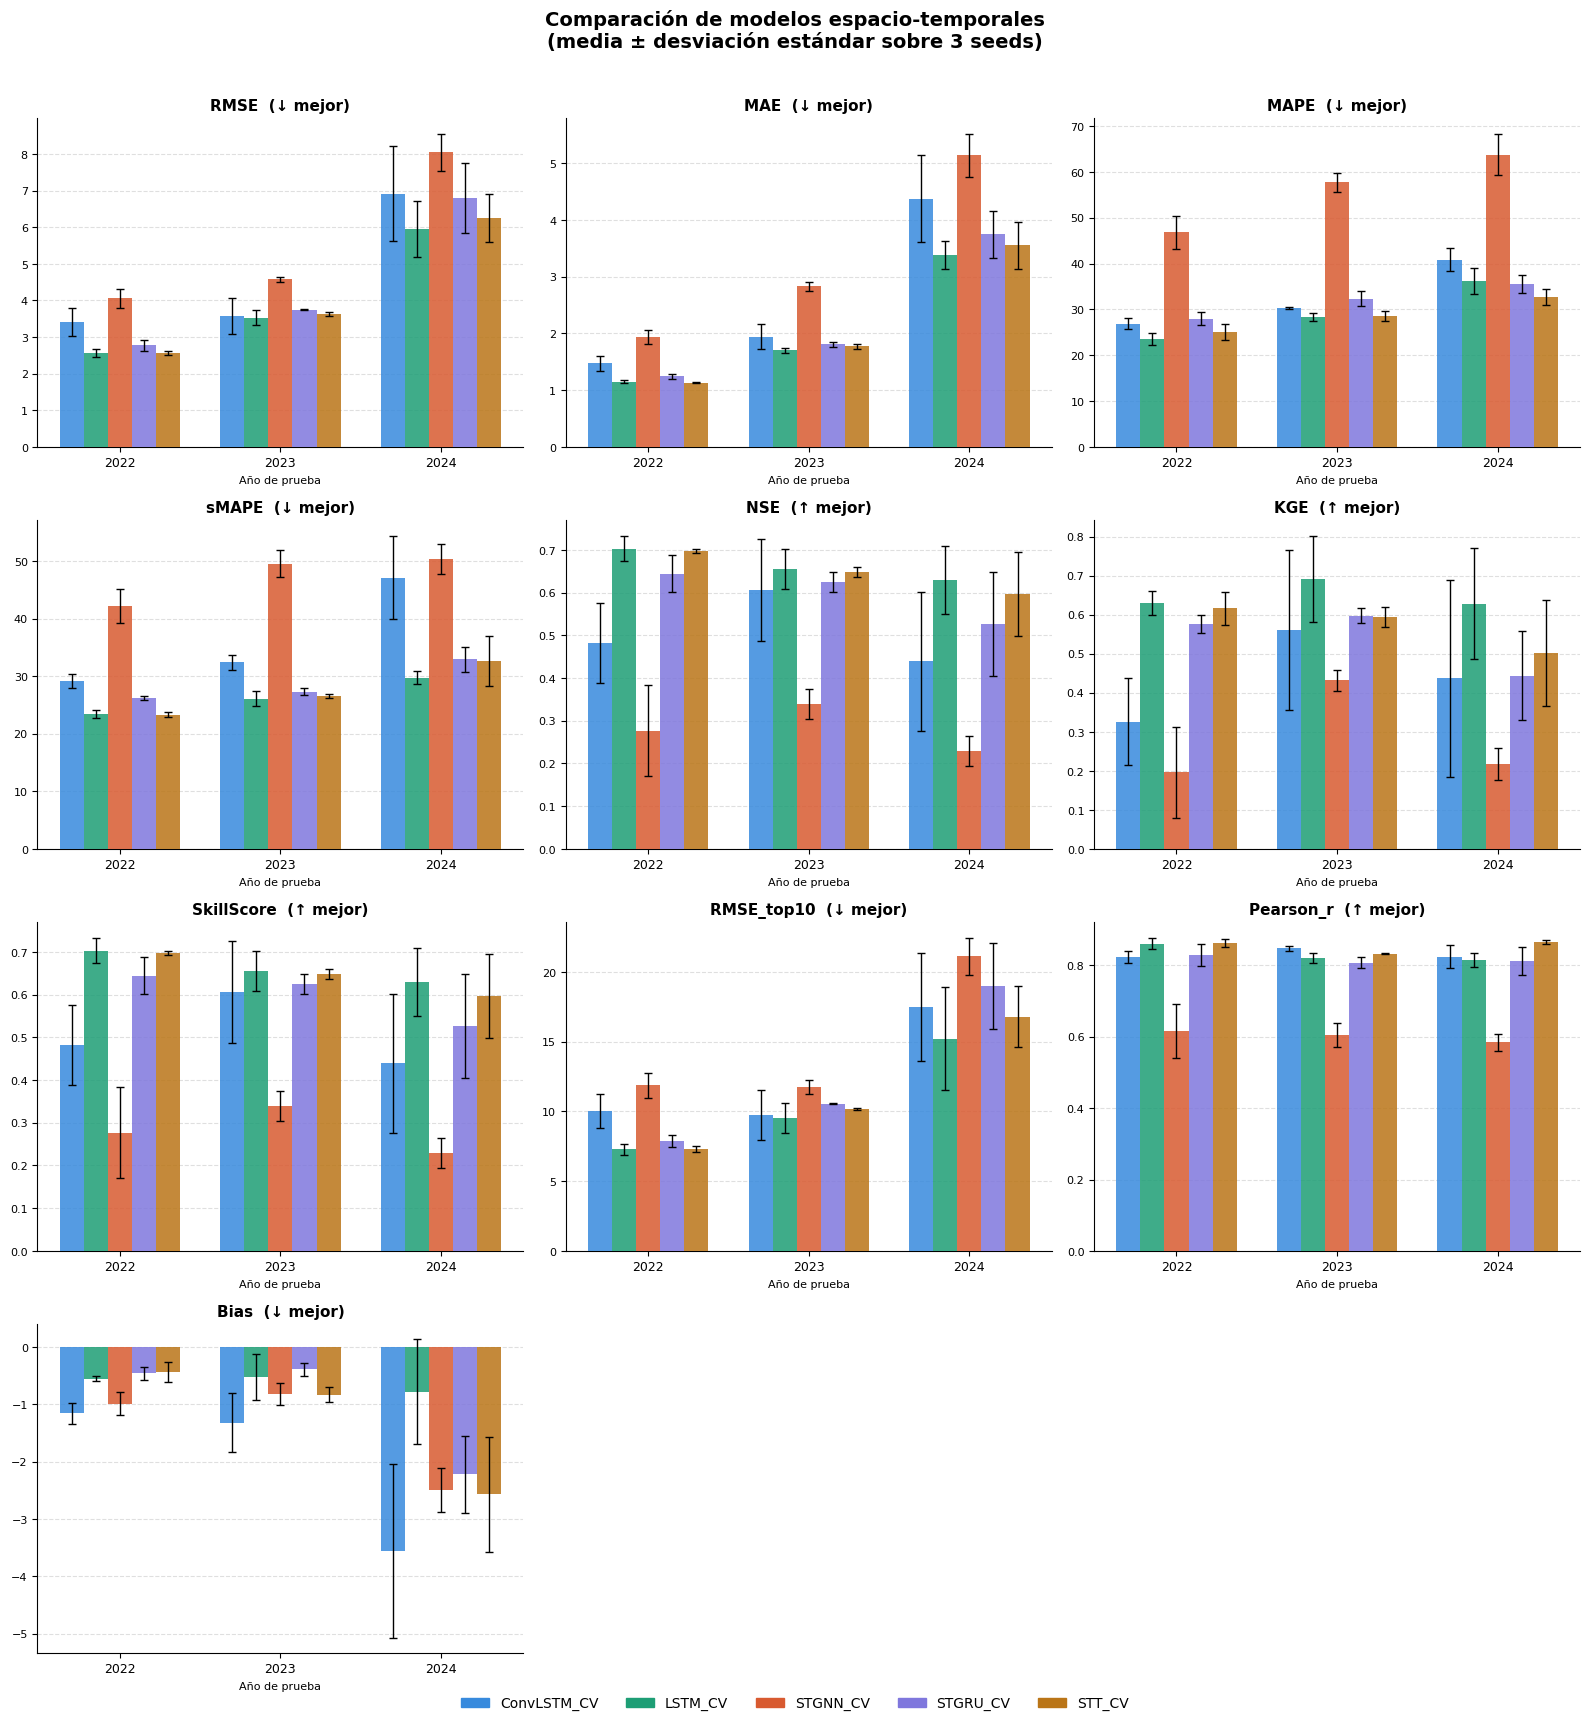

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

real_cols_mean = [c for c in summary_df.columns if c.endswith("_mean") and c.startswith("real_")]
metrics = [c.replace("real_", "").replace("_mean", "") for c in real_cols_mean]

models   = summary_df["Model"].unique()
years    = sorted(summary_df["test_year"].unique())
colors   = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD", "#BA7517"]
mod_col  = dict(zip(models, colors))

# Métricas donde MENOR es mejor vs MAYOR es mejor
lower_better = {"RMSE", "MAE", "MAPE", "sMAPE", "RMSE_top10", "Bias"}
higher_better = {"NSE", "KGE", "SkillScore", "Pearson_r"}

n_metrics = len(metrics)
n_cols    = 3
n_rows    = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4.2))
axes = axes.flatten()

x     = np.arange(len(years))
width = 0.15
offsets = np.linspace(-(len(models)-1)/2, (len(models)-1)/2, len(models)) * width

for i, metric in enumerate(metrics):
    ax = axes[i]
    mean_col = f"real_{metric}_mean"
    std_col  = f"real_{metric}_std"

    for j, model in enumerate(models):
        df_m  = summary_df[summary_df["Model"] == model].sort_values("test_year")
        means = df_m[mean_col].values
        stds  = df_m[std_col].values

        ax.bar(x + offsets[j], means, width,
               label=model, color=mod_col[model],
               alpha=0.85, zorder=3)
        ax.errorbar(x + offsets[j], means, yerr=stds,
                    fmt="none", color="black",
                    capsize=3, linewidth=1, zorder=4)

    direction = "↓ mejor" if metric in lower_better else "↑ mejor"
    ax.set_title(f"{metric}  ({direction})", fontsize=11, fontweight="bold", pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels([str(y) for y in years], fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("Año de prueba", fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# Ocultar subplots vacíos
for k in range(i + 1, len(axes)):
    axes[k].set_visible(False)

# Leyenda global
handles = [mpatches.Patch(color=mod_col[m], label=m) for m in models]
fig.legend(handles=handles, loc="lower center", ncol=len(models),
           fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Comparación de modelos espacio-temporales\n(media ± desviación estándar sobre 3 seeds)",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

La gráfica confirma y enriquece visualmente el análisis previo. Lo más destacable es que **LSTM y STT (Transformer) dominan de forma consistente** en casi todas las métricas y años — sus barras son sistemáticamente las más bajas en errores (RMSE, MAE, MAPE) y las más altas en calidad (NSE, KGE, SkillScore, Pearson_r), con barras de error pequeñas que reflejan alta estabilidad entre seeds. **STGNN es el outlier negativo más evidente**: en MAPE su barra naranja se dispara a ~47% en 2022 y llega casi a 64% en 2024, y en NSE colapsa hasta ~0.25 en 2023, lo que visualmente lo separa del grupo de forma dramática — esto sugiere que el modelo de grafos no está capturando correctamente la estructura espacio-temporal del problema, posiblemente por una construcción inadecuada del grafo o insuficiente información de conectividad entre nodos. **ConvLSTM muestra un comportamiento peculiar**: en Pearson_r se mantiene competitivo (~0.82–0.85), pero en SkillScore y KGE queda por debajo de lo esperado, lo que indica que captura la correlación temporal pero falla en reproducir la magnitud y distribución de los valores, un desacople clásico entre forma y escala de la señal. El **Bias negativo generalizado** en todos los modelos confirma una subestimación sistemática, que se agrava fuertemente en 2024 — especialmente en ConvLSTM (Bias ≈ −3.5) — y el **RMSE_top10** que se duplica o triplica en 2024 revela que el fallo de 2024 se concentra en los eventos de mayor magnitud, no en el promedio general, lo que es crítico si el objetivo de la aplicación involucra alertas o gestión de extremos hidrológicos.


### **10.3.2. Métricas anuales por modelo**

In [11]:
summary_overall = (
    metrics_global_df
    .groupby("Model")[real_cols]
    .agg(["mean", "std"])
    .round(4)
)
summary_overall.columns = [f"{col}_{stat}" for col, stat in summary_overall.columns]
summary_overall = summary_overall.reset_index()

display(summary_overall)

,Model,real_RMSE_mean,real_RMSE_std,real_MAE_mean,real_MAE_std,real_MAPE_mean,real_MAPE_std,real_sMAPE_mean,real_sMAPE_std,real_NSE_mean,...,real_KGE_mean,real_KGE_std,real_SkillScore_mean,real_SkillScore_std,real_RMSE_top10_mean,real_RMSE_top10_std,real_Pearson_r_mean,real_Pearson_r_std,real_Bias_mean,real_Bias_std
0,ConvLSTM_CV,4.6362,1.8552,2.5994,1.4093,32.6815,6.4673,36.2084,9.0733,0.5089,...,0.4413,0.1994,0.5089,0.1342,12.4064,4.4027,0.8319,0.0220,-2.0127,1.4158
1,LSTM_CV,4.0069,1.5629,2.0781,1.0179,29.3527,5.7694,26.3951,2.8773,0.6627,...,0.6499,0.0963,0.6627,0.0583,10.6818,4.0336,0.8325,0.0261,-0.6192,0.5106
2,STGNN_CV,5.5598,1.8981,3.3008,1.4464,56.0807,8.0441,47.3598,4.4739,0.2817,...,0.2819,0.1292,0.2817,0.0757,14.9218,4.7190,0.6023,0.0454,-1.4329,0.8317
3,STGRU_CV,4.4393,1.8773,2.2652,1.1557,31.9374,3.5798,28.8041,3.3597,0.5989,...,0.5396,0.0934,0.5989,0.0852,12.4724,5.2648,0.8171,0.0277,-1.0261,0.9606
4,STT_CV,4.1482,1.6754,2.1532,1.1064,28.8091,3.6071,27.5132,4.6306,0.6480,...,0.5711,0.0892,0.6480,0.0659,11.4159,4.3664,0.8544,0.0170,-1.2821,1.1101


Esta tabla muestra el **promedio agregado sobre los tres años de prueba**, y el panorama es claro: **LSTM lidera globalmente** con el menor RMSE (4.01), mejor NSE (0.663) y KGE (0.650), y el sesgo más bajo en valor absoluto (−0.62), lo que lo convierte en el modelo más preciso y menos sesgado en promedio. **STT (Transformer) queda en segundo lugar muy cercano** — RMSE de 4.15 y NSE de 0.648 — con la ventaja de tener el mejor Pearson_r (0.854) y el menor MAPE (28.8%), lo que sugiere que captura mejor la forma relativa de la señal aunque subestima ligeramente más que LSTM (Bias: −1.28). **STGRU ocupa el tercer lugar** con métricas intermedias y razonables, mientras que **ConvLSTM cae al cuarto puesto**: a pesar de mantener un Pearson_r competitivo (0.832), su NSE de solo 0.509 y su Bias de −2.01 revelan el desacople ya identificado entre correlación y precisión real. Finalmente, **STGNN confirma su bajo rendimiento global** — NSE de 0.28, MAPE del 56%, KGE de 0.28 y Pearson_r de apenas 0.60 — siendo el único modelo que no supera de forma convincente una predicción de referencia simple. Un elemento importante que revelan las desviaciones estándar elevadas en todos los modelos es que la variabilidad entre años es muy alta (los std son casi tan grandes como las medias en varios casos), lo que refuerza que el comportamiento de 2024 no es un ruido menor sino una ruptura estructural que cualquier análisis de rendimiento debe reportar separado del promedio agregado.

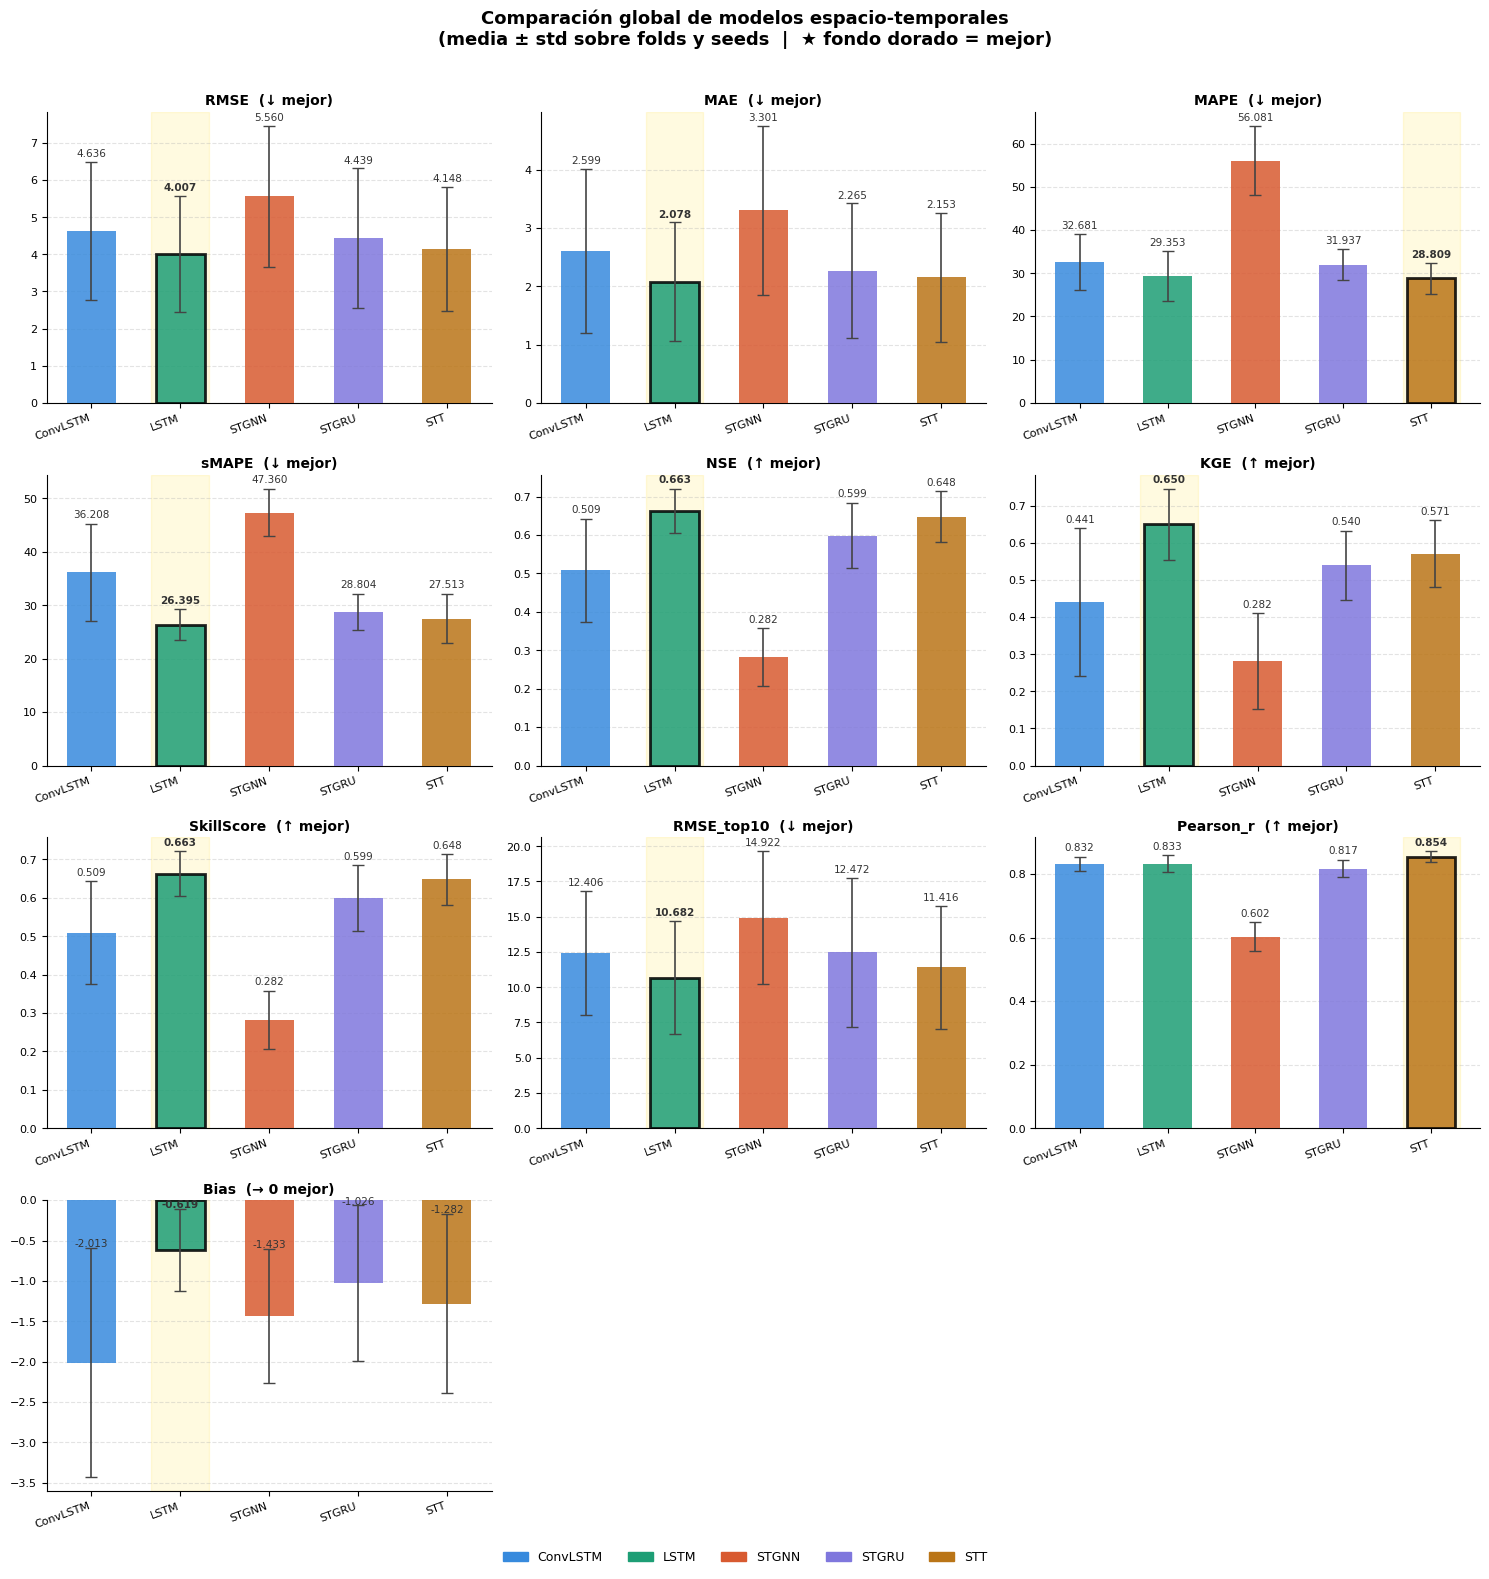

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models   = summary_overall["Model"].values
colors   = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD", "#BA7517"]
mod_col  = dict(zip(models, colors))

real_cols_mean = [c for c in summary_overall.columns if c.endswith("_mean") and c.startswith("real_")]
metrics        = [c.replace("real_", "").replace("_mean", "") for c in real_cols_mean]

lower_better  = {"RMSE", "MAE", "MAPE", "sMAPE", "RMSE_top10"}
higher_better = {"NSE", "KGE", "SkillScore", "Pearson_r"}
# Bias: neutro (más cercano a 0 es mejor), se marca aparte
bias_metrics  = {"Bias"}

n_metrics = len(metrics)
n_cols    = 3
n_rows    = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.8))
axes = axes.flatten()

x      = np.arange(len(models))
width  = 0.55

for i, metric in enumerate(metrics):
    ax = axes[i]
    mean_col = f"real_{metric}_mean"
    std_col  = f"real_{metric}_std"

    means = summary_overall[mean_col].values
    stds  = summary_overall[std_col].values

    # Identificar el mejor modelo según la métrica
    if metric in lower_better:
        best_idx = np.argmin(means)
        direction = "↓ mejor"
    elif metric in higher_better:
        best_idx = np.argmax(means)
        direction = "↑ mejor"
    else:  # Bias → más cercano a 0
        best_idx = np.argmin(np.abs(means))
        direction = "→ 0 mejor"

    bar_colors = [mod_col[m] for m in models]

    bars = ax.bar(x, means, width,
                  color=bar_colors, alpha=0.85, zorder=3,
                  edgecolor="none")

    # Resaltar el mejor con borde negro
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2.0)

    ax.errorbar(x, means, yerr=stds,
                fmt="none", color="#444", capsize=4,
                linewidth=1.2, zorder=4)

    # Etiqueta de valor encima de cada barra
    for j, (bar, val) in enumerate(zip(bars, means)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + stds[j] + (max(means) * 0.015),
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7.5, color="#333",
                fontweight="bold" if j == best_idx else "normal")

    ax.set_title(f"{metric}  ({direction})", fontsize=10,
                 fontweight="bold", pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("_CV", "") for m in models],
                        fontsize=8, rotation=20, ha="right")
    ax.tick_params(axis="y", labelsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    # Franja de fondo para resaltar ganador
    ax.axvspan(x[best_idx] - width/2 - 0.05,
               x[best_idx] + width/2 + 0.05,
               color="gold", alpha=0.12, zorder=0)

# Ocultar subplots vacíos
for k in range(i + 1, len(axes)):
    axes[k].set_visible(False)

# Leyenda global
handles = [mpatches.Patch(color=mod_col[m], label=m.replace("_CV", ""))
           for m in models]
fig.legend(handles=handles, loc="lower center", ncol=len(models),
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Comparación global de modelos espacio-temporales\n"
             "(media ± std sobre folds y seeds  |  ★ fondo dorado = mejor)",
             fontsize=13, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("comparacion_global_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

La gráfica global con el fondo dorado marcando al ganador en cada métrica lo dice todo de forma visual: **LSTM gana en 6 de 9 métricas** (RMSE, MAE, sMAPE, NSE, KGE, SkillScore, RMSE_top10), consolidándose como el modelo más equilibrado y confiable del benchmark. **STT (Transformer) gana en MAPE y Pearson_r**, lo que confirma su fortaleza en capturar la forma y tendencia relativa de la señal, pero su mayor Bias (−1.28) frente al de LSTM (−0.62) explica por qué no domina en métricas absolutas. Lo más revelador de la visualización es la **brecha enorme de STGNN** — su barra en MAPE (56%) casi duplica a cualquier otro modelo, su NSE (0.28) y KGE (0.28) están a mitad del camino de los demás, y su Pearson_r (0.60) es el único por debajo de 0.80, lo que en conjunto indica que este modelo no solo comete errores grandes sino que tampoco sigue la dinámica temporal del fenómeno. Las **barras de error amplias en RMSE_top10** de todos los modelos (~±4–5 unidades) reafirman la alta incertidumbre en eventos extremos, siendo este el talón de Aquiles compartido. En síntesis, para este problema **LSTM es la recomendación principal**, STT es una alternativa válida si se prioriza la forma de la señal sobre la magnitud, STGRU es una opción eficiente de menor complejidad, ConvLSTM no justifica su costo computacional adicional dado su rendimiento, y STGNN debería descartarse o revisarse estructuralmente antes de considerarse operativo.

### **10.3.3. Métricas espaciales test year por modelo**

In [30]:
import os
import pandas as pd

BASE_DIR = "/home/moon/DEEP/PF/PF_DG/MODELOS"
MODELOS  = ["LSTM_CV", "ConvLSTM_CV", "STGNN_CV", "STGRU_CV", "STT_CV"]

METRICS_BASE = [
    "RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
    "SkillScore", "RMSE_top10", "Pearson_r", "Bias"
]

spatial_list = []

for model in MODELOS:

    model_path = os.path.join(BASE_DIR, model)

    if not os.path.isdir(model_path):
        print(f"[WARNING] No existe directorio: {model_path}")
        continue

    all_files = [f for f in os.listdir(model_path) if f.endswith(".csv")]

    spatial_files = [
        f for f in all_files
        if f.lower().endswith("_spatial_fold_results.csv")
    ]

    if not spatial_files:
        print(f"[WARNING] {model}: no existe archivo *_spatial_fold_results.csv")
        continue

    fp = os.path.join(model_path, spatial_files[0])

    try:
        df = pd.read_csv(fp)

        metric_cols = [c for c in df.columns if c in METRICS_BASE]
        other_cols  = [c for c in df.columns if c not in METRICS_BASE]

        spatial_df = df[other_cols + metric_cols].copy()
        spatial_df["Model"] = model

        spatial_list.append(spatial_df)

    except Exception as e:
        print(f"[ERROR] {model}: {e}")

metrics_spatial_df = (
    pd.concat(spatial_list, ignore_index=True)
    if spatial_list else pd.DataFrame()
)

if not metrics_spatial_df.empty:
    metrics_spatial_df = metrics_spatial_df[
        ["Model"] +
        [c for c in metrics_spatial_df.columns if c != "Model"]
    ]

print("Modelos encontrados:")
if not metrics_spatial_df.empty:
    print(metrics_spatial_df["Model"].unique())

print("\nShape:", metrics_spatial_df.shape)

metrics_spatial_df.head()

Modelos encontrados:
<ArrowStringArray>
['LSTM_CV', 'ConvLSTM_CV', 'STGNN_CV', 'STGRU_CV', 'STT_CV']
Length: 5, dtype: str

Shape: (180, 17)


,Model,seed,outer_fold,test_year,spatial_fold,n_departamentos,departamentos,RMSE,MAE,MAPE,sMAPE,NSE,KGE,SkillScore,RMSE_top10,Pearson_r,Bias
0,LSTM_CV,42,1,2022,1,8,"['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', '...",1.883266,1.256367,20.219804,21.842342,0.681618,0.717342,0.681618,4.189540,0.851588,-0.680634
1,LSTM_CV,42,1,2022,2,5,"['Caqueta', 'Cauca', 'Huila', 'Narino', 'Putum...",1.164582,0.714591,20.816530,20.772030,0.660180,0.793629,0.660180,2.846778,0.819361,-0.098667
2,LSTM_CV,42,1,2022,3,12,"['Antioquia', 'Bogota d.c.', 'Boyaca', 'Caldas...",0.560327,0.352074,16.794206,15.925474,0.786320,0.823008,0.786320,1.313747,0.887953,0.053049
3,LSTM_CV,42,1,2022,4,3,"['Amazonas', 'Guaviare', 'Vaupes']",7.173803,4.115127,44.842019,46.219167,0.494377,0.335860,0.494377,18.016286,0.841118,-3.226468
4,LSTM_CV,42,2,2023,1,8,"['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', '...",1.353009,1.011707,18.981964,18.863594,0.685287,0.838656,0.685287,2.134339,0.855686,-0.047923


Los **4 spatial folds agrupan departamentos por región geográfica**, y lo que salta de inmediato en las primeras filas del LSTM es una **heterogeneidad espacial enorme**: el fold 3 (Antioquia, Bogotá, Boyacá, Caldas...) tiene un RMSE de apenas 0.56 y NSE de 0.79, mientras que el fold 4 (Amazonas, Guaviare, Vaupés) tiene RMSE de 7.17 y NSE de 0.49 — una diferencia de más de 10x en error —, lo que indica que el modelo funciona muy bien en la región Andina/Central pero tiene dificultades serias en la Amazonía, probablemente por menor densidad de datos de entrenamiento, mayor variabilidad hidrológica local, o patrones de precipitación cualitativamente distintos. El fold 1 (Atlántico, Bolívar, Cesar, Córdoba — Costa Caribe) y el fold 2 (Caquetá, Cauca, Huila, Nariño, Putumayo — Pacífico/Sur) muestran desempeños intermedios. Esto es crítico porque los promedios globales reportados antes **enmascaran estas diferencias regionales**: un modelo puede tener un NSE promedio de 0.66 pero estar fallando sistemáticamente en zonas específicas del país. El siguiente paso natural sería analizar el rendimiento por spatial fold en todos los modelos para identificar si la superioridad de LSTM sobre, por ejemplo, STGNN, se mantiene uniformemente en todas las regiones o si hay alguna donde STGNN o STT sean competitivos.

In [31]:
metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
    "SkillScore", "RMSE_top10", "Pearson_r", "Bias"
]

summary_spatial = (
    metrics_spatial_df
    .groupby(
        ["Model", "test_year", "spatial_fold"],
        as_index=False
    )[metric_cols]
    .agg(["mean", "std"])
)

summary_spatial.columns = [
    "_".join(col).strip("_")
    for col in summary_spatial.columns
]

summary_spatial = summary_spatial.rename(
    columns={
        "Model_": "Model",
        "test_year_": "test_year",
        "spatial_fold_": "spatial_fold"
    }
)

summary_spatial.head()

,Model,test_year,spatial_fold,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,sMAPE_mean,...,KGE_mean,KGE_std,SkillScore_mean,SkillScore_std,RMSE_top10_mean,RMSE_top10_std,Pearson_r_mean,Pearson_r_std,Bias_mean,Bias_std
0,ConvLSTM_CV,2022,1,2.784339,0.352558,1.873040,0.244197,25.861333,1.259605,30.922631,...,0.392492,0.115989,0.327616,0.144519,6.796157,1.076832,0.819483,0.039958,-1.682055,0.289123
1,ConvLSTM_CV,2022,2,1.305861,0.086011,0.811829,0.037368,24.573815,0.580244,28.649761,...,0.453962,0.097520,0.490247,0.095638,3.379056,0.287768,0.807572,0.037107,-0.649819,0.022217
2,ConvLSTM_CV,2022,3,0.744350,0.075946,0.407297,0.037653,16.105637,1.257511,17.197053,...,0.681024,0.073897,0.636233,0.072770,1.953049,0.203534,0.819310,0.052099,-0.173696,0.046343
3,ConvLSTM_CV,2022,4,9.376202,1.142658,5.450305,0.715062,49.587426,2.443526,55.268486,...,0.083250,0.095163,0.219851,0.123703,24.149238,3.119731,0.843656,0.033386,-4.829490,0.783256
4,ConvLSTM_CV,2023,1,1.802990,0.364866,1.412364,0.287702,23.773343,1.866145,25.723692,...,0.602965,0.166967,0.408527,0.248229,3.276394,1.008607,0.791081,0.052970,-0.891586,0.611619


Este desglose por spatial fold confirma y cuantifica con precisión lo anticipado: **el fold 4 (Amazonía — Amazonas, Guaviare, Vaupés) es el responsable principal de los malos promedios globales** en todos los modelos. Solo mirando ConvLSTM en 2022, el fold 4 tiene RMSE de 9.38, MAPE de 49.6%, KGE de apenas 0.08 y un Bias de −4.83, mientras que el fold 3 (región Andina) tiene RMSE de 0.74, MAPE de 16.1% y KGE de 0.68 — una diferencia de **12x en RMSE y 6x en MAPE dentro del mismo modelo y año**. El fold 2 (Pacífico/Sur) es consistentemente el más fácil de predecir (RMSE más bajo, errores compactos), y el fold 1 (Costa Caribe) ocupa una posición intermedia. Esto tiene una interpretación hidrológica directa: la Amazonía colombiana combina **régimen de precipitación bimodal complejo, escasez histórica de estaciones de monitoreo, y eventos convectivos locales de alta variabilidad espacial** que ninguna arquitectura captura bien con los datos disponibles. El KGE de 0.08 en fold 4 es prácticamente equivalente a no predecir — un modelo climatológico simple probablemente lo igualaría. La implicación metodológica es importante: **los rankings globales de modelos están siendo dominados por el comportamiento en fold 4**, y valdría la pena analizar si el orden LSTM > STT > STGRU > ConvLSTM > STGNN se mantiene también dentro de cada fold por separado, porque es posible que para la Amazonía específicamente la jerarquía cambie.

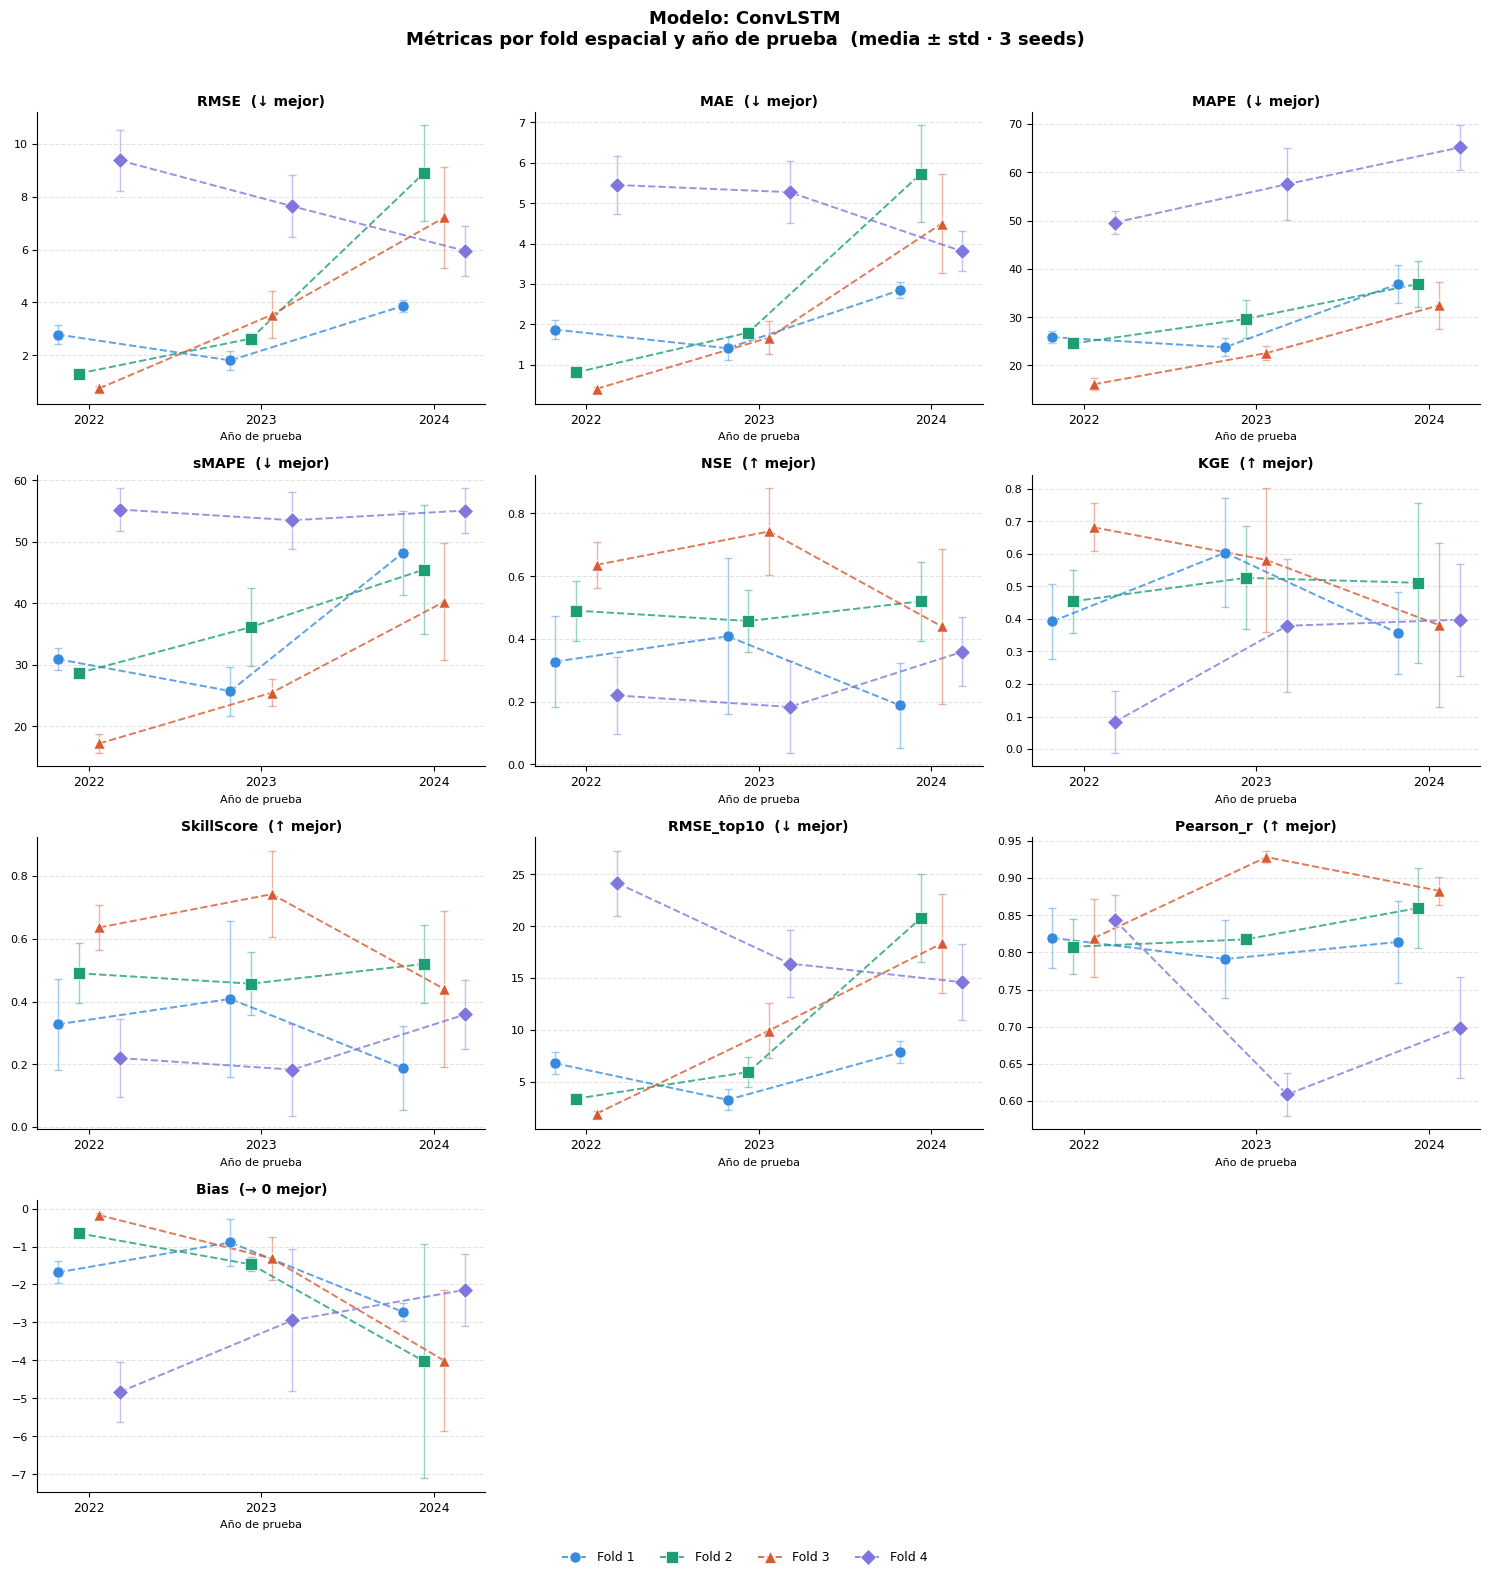

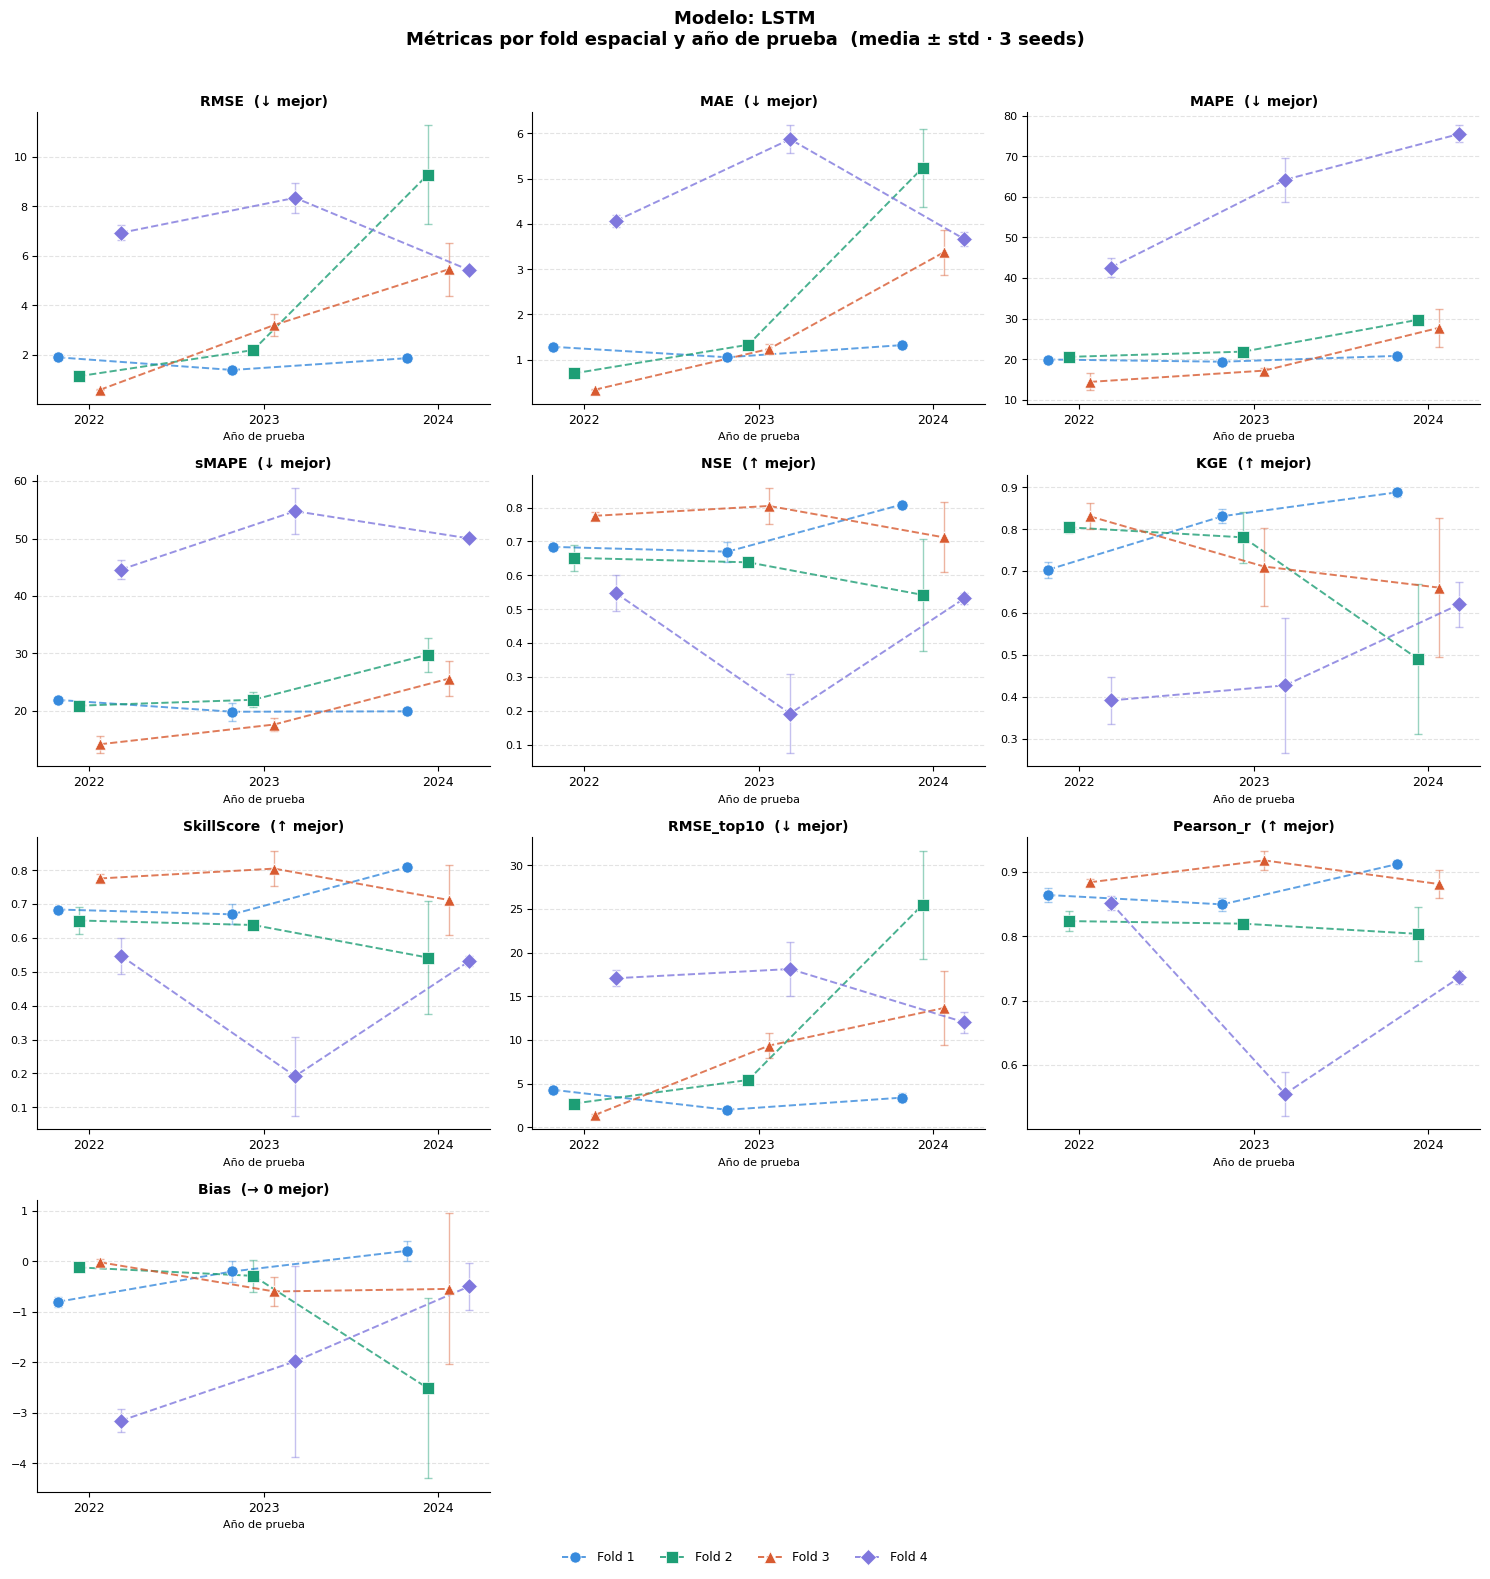

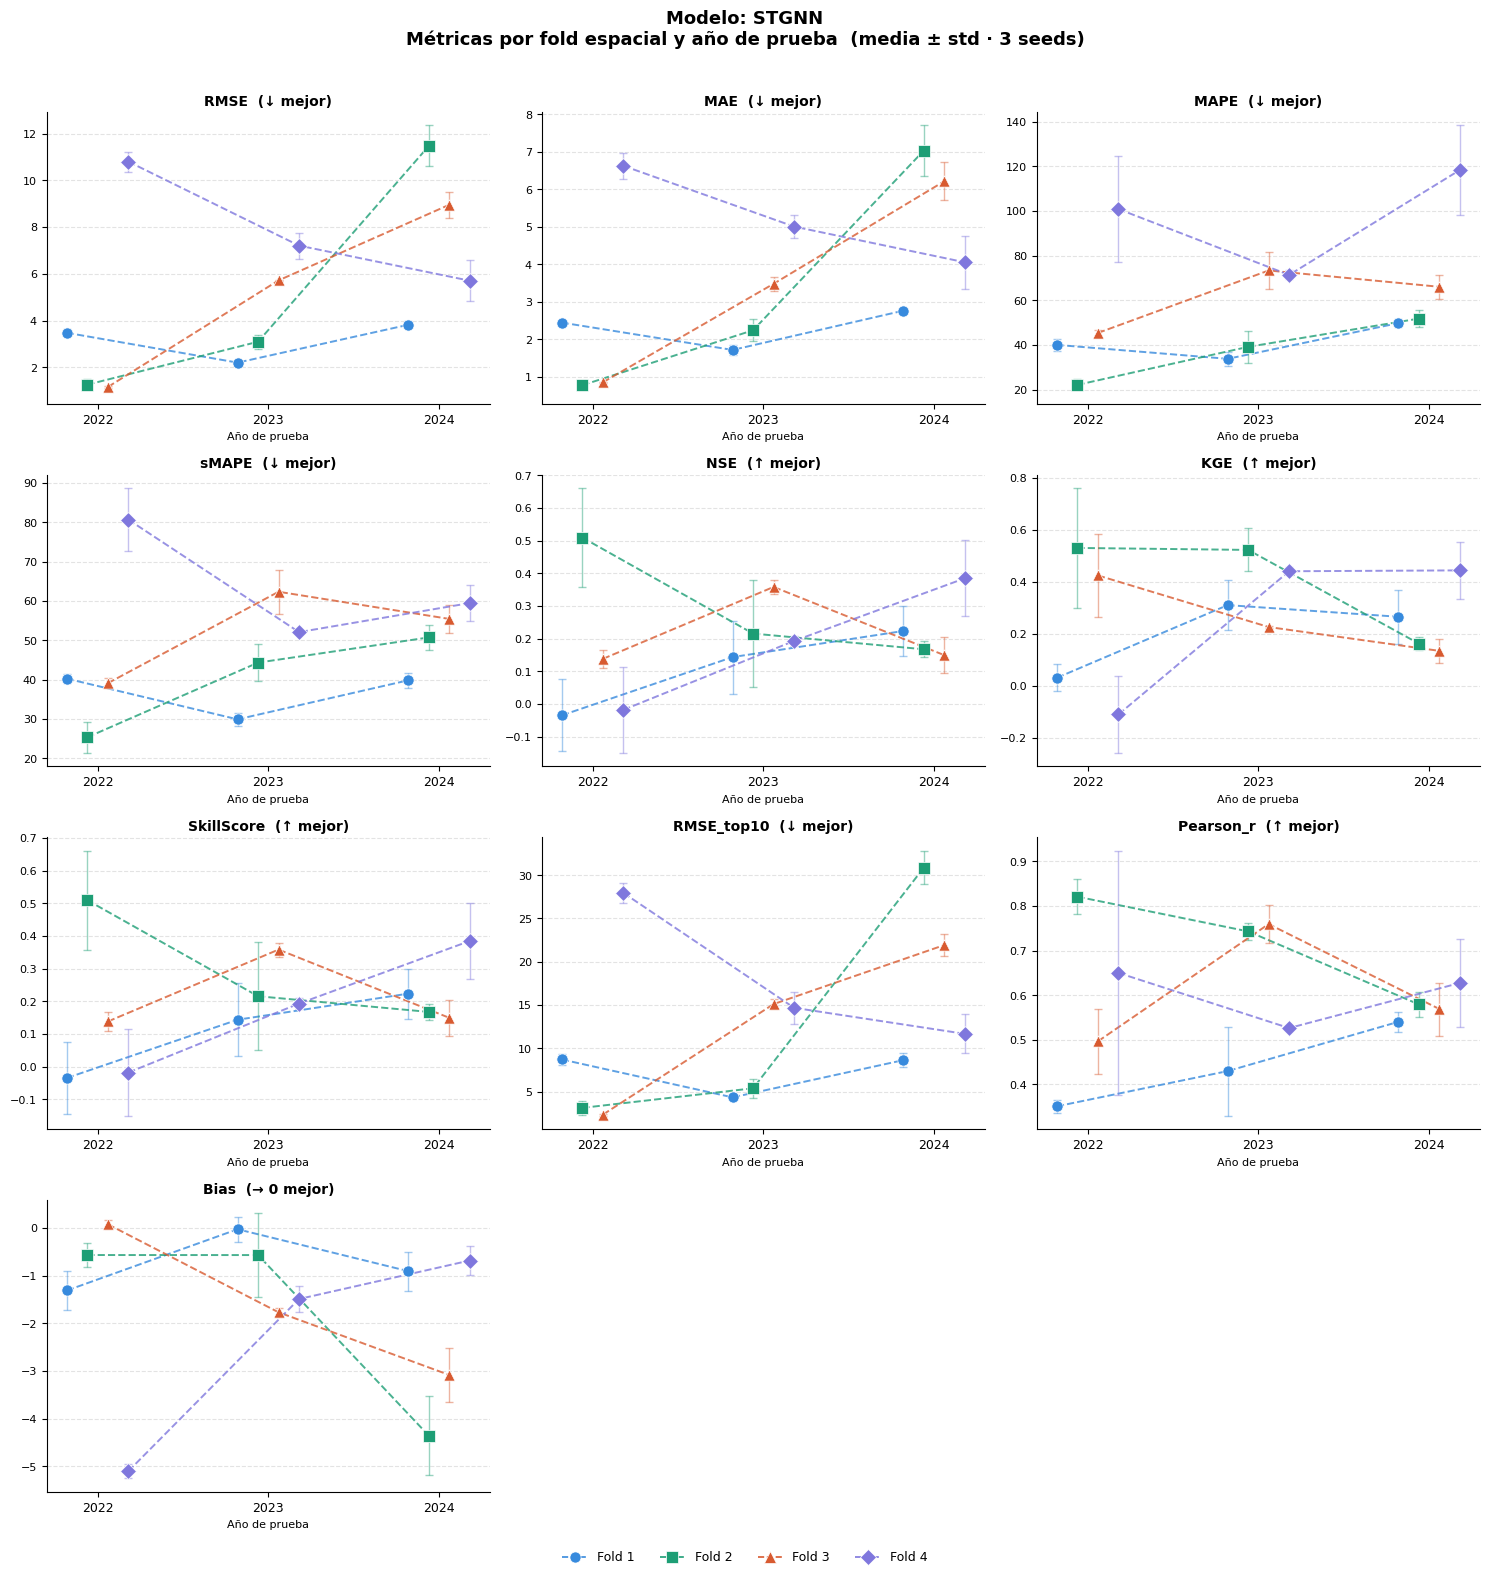

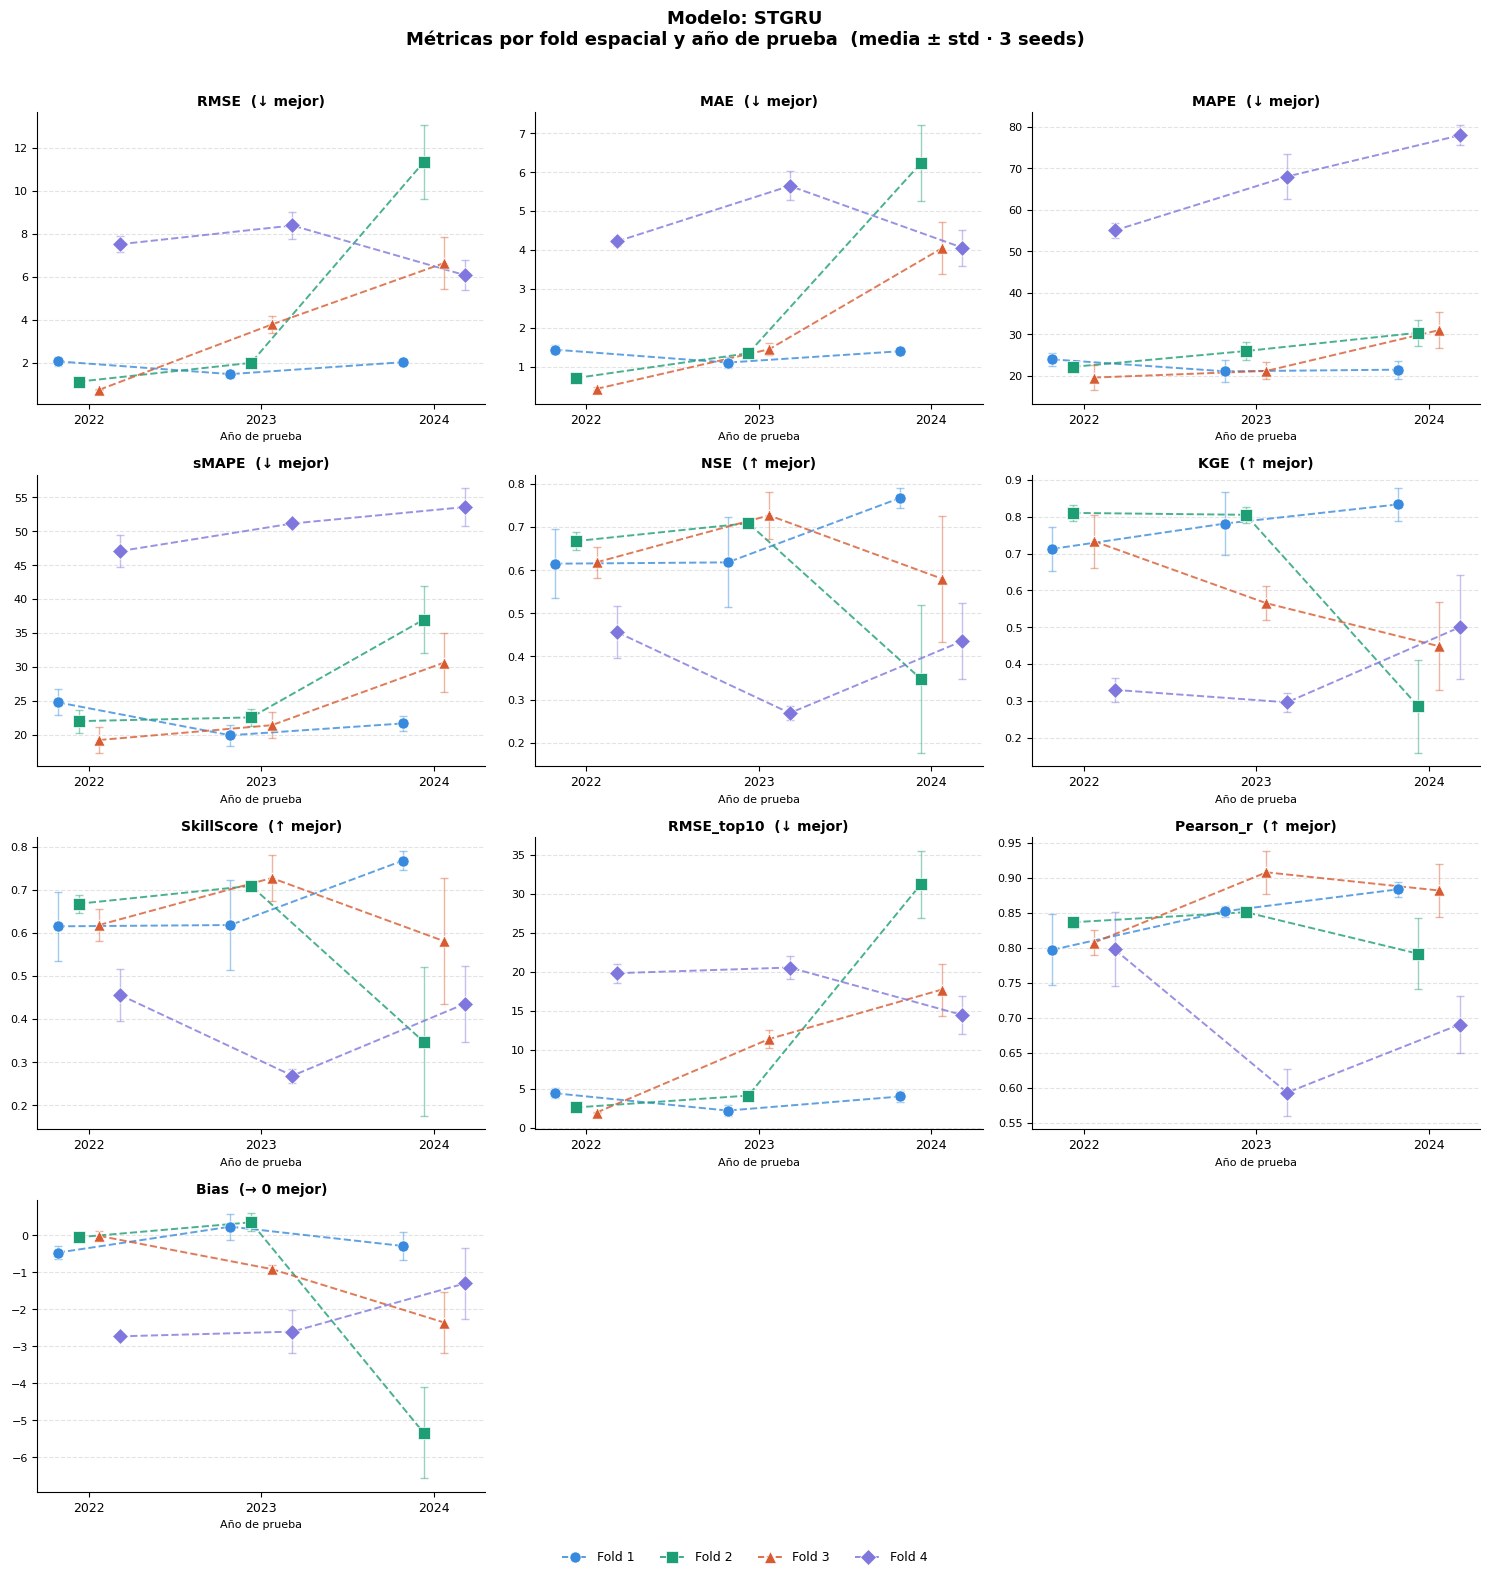

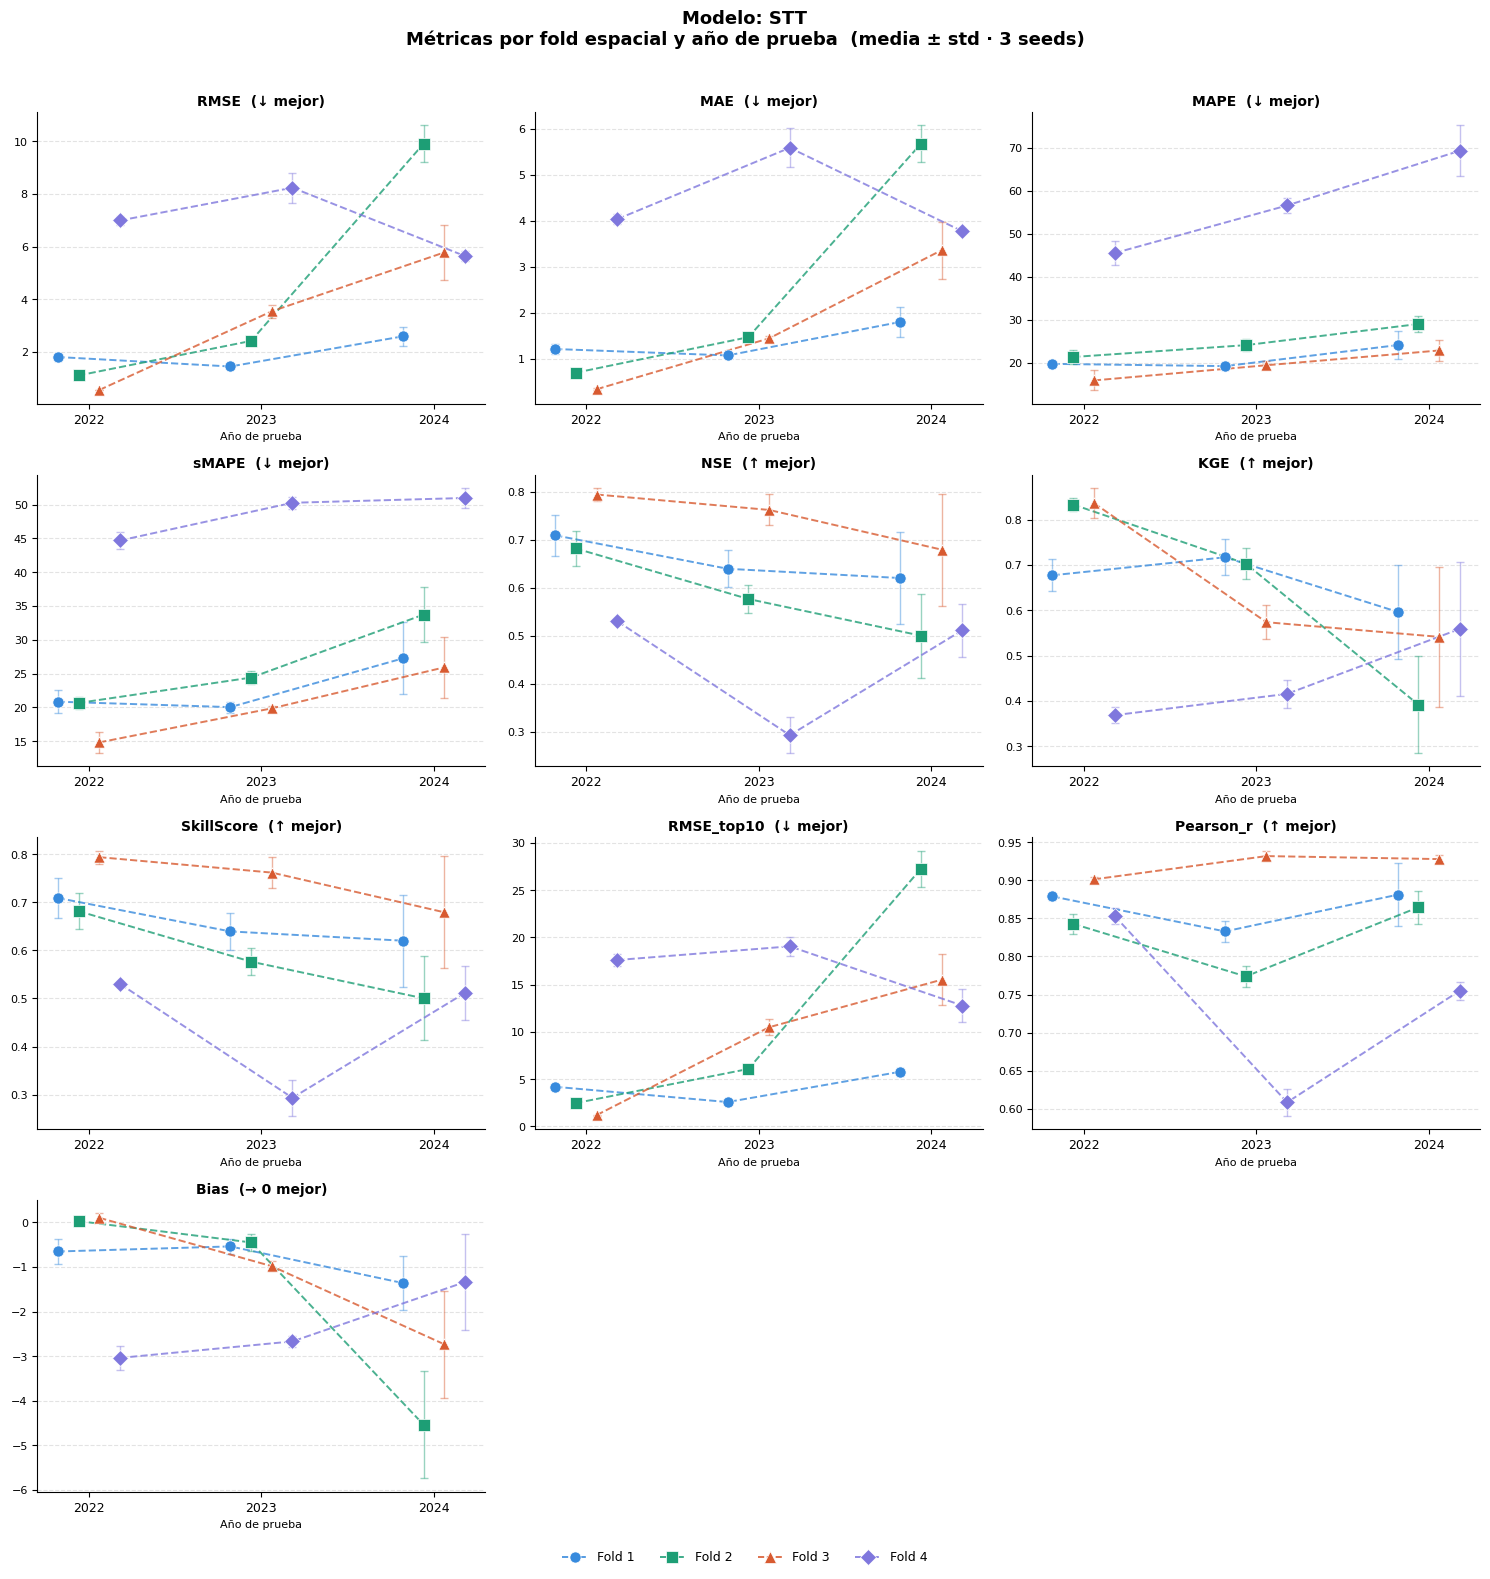

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metric_cols   = ["RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
                 "SkillScore", "RMSE_top10", "Pearson_r", "Bias"]
lower_better  = {"RMSE", "MAE", "MAPE", "sMAPE", "RMSE_top10"}
higher_better = {"NSE", "KGE", "SkillScore", "Pearson_r"}

models  = sorted(summary_spatial["Model"].unique())
years   = sorted(summary_spatial["test_year"].unique())
folds   = sorted(summary_spatial["spatial_fold"].unique())

fold_colors  = {1: "#378ADD", 2: "#1D9E75", 3: "#D85A30", 4: "#7F77DD", 5: "#BA7517"}
fold_markers = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v"}

x      = np.arange(len(years))
width  = 0.12
n_fold = len(folds)
offsets= np.linspace(-(n_fold-1)/2, (n_fold-1)/2, n_fold) * width

n_metric_cols = 3
n_metric_rows = (len(metric_cols) + n_metric_cols - 1) // n_metric_cols

for model in models:
    df_mod = summary_spatial[summary_spatial["Model"] == model]
    model_label = model.replace("_CV", "")

    fig, axes = plt.subplots(n_metric_rows, n_metric_cols,
                              figsize=(15, n_metric_rows * 3.8))
    axes = axes.flatten()

    for i, metric in enumerate(metric_cols):
        ax = axes[i]
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"

        for k, fold in enumerate(folds):
            df_f = df_mod[df_mod["spatial_fold"] == fold].sort_values("test_year")
            if df_f.empty:
                continue

            y_vals = df_f[mean_col].values
            y_stds = df_f[std_col].values
            x_pos  = x + offsets[k]

            ax.plot(x_pos, y_vals,
                    color=fold_colors[fold], alpha=0.8,
                    linewidth=1.4, linestyle="--", zorder=3)
            ax.scatter(x_pos, y_vals,
                       color=fold_colors[fold],
                       marker=fold_markers[fold],
                       s=65, zorder=4, edgecolors="white", linewidths=0.5)
            ax.errorbar(x_pos, y_vals, yerr=y_stds,
                        fmt="none", color=fold_colors[fold],
                        alpha=0.45, capsize=3, linewidth=1.0, zorder=3)

        direction = ("↓ mejor" if metric in lower_better
                     else "↑ mejor" if metric in higher_better
                     else "→ 0 mejor")
        ax.set_title(f"{metric}  ({direction})", fontsize=10,
                     fontweight="bold", pad=5)
        ax.set_xticks(x)
        ax.set_xticklabels([str(y) for y in years], fontsize=9)
        ax.tick_params(axis="y", labelsize=8)
        ax.set_xlabel("Año de prueba", fontsize=8)
        ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    for k in range(i + 1, len(axes)):
        axes[k].set_visible(False)

    # Leyenda: un handle por fold espacial
    fold_handles = [
        plt.Line2D([0], [0], marker=fold_markers[f], color=fold_colors[f],
                   linestyle="--", markersize=8, linewidth=1.2,
                   markeredgecolor="white", markeredgewidth=0.5,
                   label=f"Fold {f}")
        for f in folds
    ]
    fig.legend(handles=fold_handles, loc="lower center",
               ncol=len(folds), fontsize=9,
               frameon=False, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f"Modelo: {model_label}\n"
                 f"Métricas por fold espacial y año de prueba  "
                 f"(media ± std · 3 seeds)",
                 fontsize=13, fontweight="bold", y=1.01)

    plt.tight_layout()
    fname = f"comparacion_spatial_{model_label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

Las cinco gráficas revelan patrones espaciotemporales que los promedios globales ocultan. El principal hallazgo es que el **Fold 4 (Amazonía)** constituye la mayor dificultad para todos los modelos, manteniendo los errores más altos y los peores valores de NSE/KGE; en STGNN incluso se observan NSE negativos y MAPE superiores al 100%, evidenciando un desempeño inferior al de una predicción basada en la media.

Por el contrario, el **Fold 3 (Andina–Pacífico Sur)** presenta sistemáticamente los mejores resultados, con menores errores y mayores valores de NSE/KGE. Además, el incremento abrupto del error en el **Fold 2 durante 2024**, visible en casi todos los modelos, sugiere la ocurrencia de un evento atípico que afectó especialmente esta región.

En términos de estabilidad, **LSTM y STT** muestran trayectorias más consistentes entre folds, mientras que **STGNN** exhibe una alta variabilidad, con cruces frecuentes de líneas, barras de error amplias y dificultades particulares en la región Caribe. Finalmente, **STGRU y STT** son los únicos modelos que evidencian una mejora progresiva en el Caribe (Fold 1), indicando una mejor capacidad para capturar sus dinámicas temporales. Este comportamiento se complementa con una fuerte caída del **Bias en el Fold 2 durante 2024**, reflejando una subestimación sistemática de los casos en esa región por parte de todos los modelos.


### **10.3.4. Métricas anuales espaciales por modelos**

In [42]:
metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

mean_cols = [f"{m}_mean" for m in metric_cols]

summary_year = (
    summary_spatial
    .groupby(["Model", "test_year"], as_index=False)[mean_cols]
    .agg(["mean", "std"])
)

summary_year.columns = [
    "_".join(col).strip("_")
    for col in summary_year.columns
]

summary_year = summary_year.rename(columns={
    "Model_": "Model",
    "test_year_": "test_year"
})

summary_year.head()

,Model,test_year,RMSE_mean_mean,RMSE_mean_std,MAE_mean_mean,MAE_mean_std,MAPE_mean_mean,MAPE_mean_std,sMAPE_mean_mean,sMAPE_mean_std,...,KGE_mean_mean,KGE_mean_std,SkillScore_mean_mean,SkillScore_mean_std,RMSE_top10_mean_mean,RMSE_top10_mean_std,Pearson_r_mean_mean,Pearson_r_mean_std,Bias_mean_mean,Bias_mean_std
0,ConvLSTM_CV,2022,3.552688,3.976542,2.135618,2.294603,29.032053,14.370629,33.009483,16.008938,...,0.402682,0.246472,0.418487,0.182826,9.069375,10.256569,0.822505,0.015163,-1.833765,2.094035
1,ConvLSTM_CV,2023,3.901701,2.591140,2.539922,1.828907,33.383512,16.404142,35.212843,13.184698,...,0.522175,0.100889,0.447833,0.229996,8.895322,5.703996,0.786420,0.132517,-1.654793,0.891741
2,ConvLSTM_CV,2024,6.481700,2.116157,4.220314,1.210416,42.835198,15.016570,47.268549,6.175952,...,0.411503,0.068269,0.376687,0.141945,15.390148,5.637858,0.813820,0.081960,-3.221958,0.942437
3,LSTM_CV,2022,2.635607,2.913200,1.594768,1.693200,24.397989,12.445615,25.412289,13.239494,...,0.682434,0.201861,0.664754,0.094053,6.369654,7.226546,0.855715,0.025179,-1.023070,1.464093
4,LSTM_CV,2023,3.781262,3.133294,2.372266,2.336652,30.685401,22.433217,28.556398,17.562532,...,0.687406,0.180423,0.576243,0.266141,8.720535,6.948764,0.785396,0.158811,-0.765281,0.827461


In [44]:
metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

summary_annual_spatial = (
    summary_spatial
    .groupby(["Model", "test_year"], as_index=False)
    [[f"{m}_mean" for m in metric_cols]]
    .mean()
)

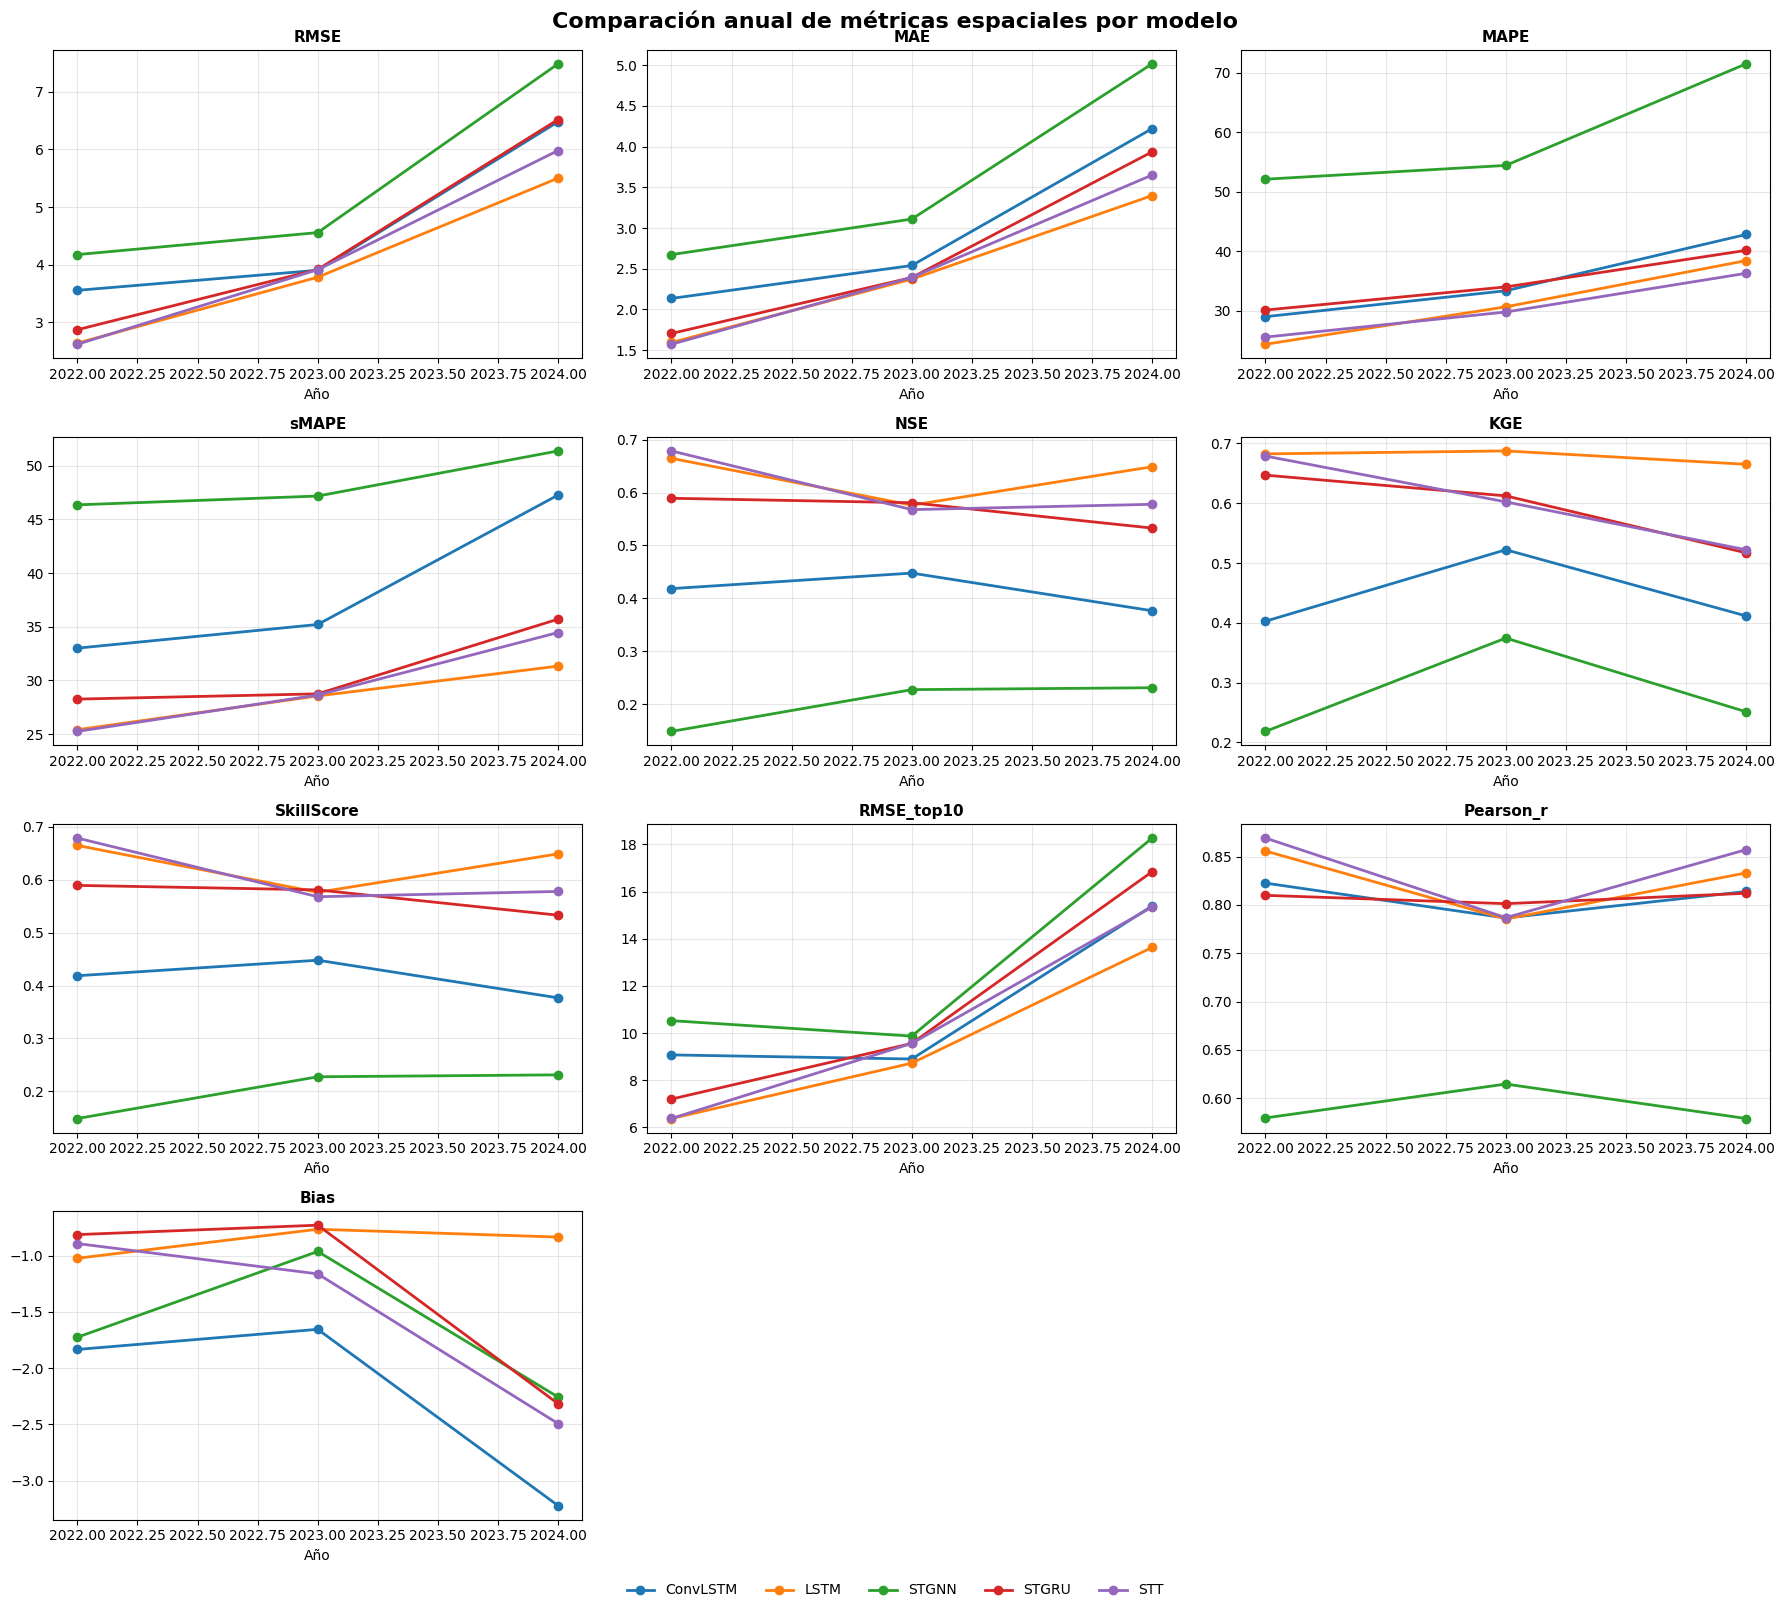

In [46]:
import matplotlib.pyplot as plt
import numpy as np

metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

models = sorted(summary_annual_spatial["Model"].unique())

ncols = 3
nrows = int(np.ceil(len(metric_cols)/ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, nrows * 4)
)

axes = axes.flatten()

for i, metric in enumerate(metric_cols):

    ax = axes[i]

    for model in models:

        df_mod = (
            summary_annual_spatial
            .query("Model == @model")
            .sort_values("test_year")
        )

        ax.plot(
            df_mod["test_year"],
            df_mod[f"{metric}_mean"],
            marker="o",
            linewidth=2,
            label=model.replace("_CV", "")
        )

    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.set_xlabel("Año")
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(models),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False
)

plt.suptitle(
    "Comparación anual de métricas espaciales por modelo",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Las cinco gráficas evidencian patrones espaciotemporales que no son visibles en las métricas globales. El principal hallazgo es que el **Fold 4 (Amazonía)** representa la mayor dificultad para todos los modelos, concentrando los errores más altos y los peores valores de NSE/KGE durante todo el período analizado. En contraste, el **Fold 3 (Andina–Pacífico Sur)** presenta consistentemente el mejor desempeño, con menores errores y mayores capacidades predictivas. Asimismo, el aumento abrupto del error en el **Fold 2 durante 2024** sugiere la ocurrencia de un evento atípico que afectó especialmente esta región.

En cuanto a la estabilidad, **LSTM y STT** muestran comportamientos más consistentes entre folds, mientras que **STGNN** exhibe una mayor variabilidad y dificultades para representar adecuadamente algunas dependencias espaciales, particularmente en la región Caribe. Además, **STGRU y STT** son los únicos modelos que presentan una mejora progresiva en el Caribe (Fold 1), lo que indica una mejor captura de sus dinámicas temporales. Finalmente, la marcada caída del Bias en el **Fold 2 durante 2024** refleja una subestimación sistemática de los casos por parte de todos los modelos, consistente con un comportamiento epidemiológico excepcional que quedó fuera de la distribución observada durante el entrenamiento.


## **10.4. Variabilidad**

In [ ]:
metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

variability = (
    metrics_spatial_df
    .groupby("Model")[metric_cols]
    .std()
    .reset_index()
)

variability

In [34]:
cv_table = pd.DataFrame()

for metric in metric_cols:

    tmp = (
        metrics_spatial_df
        .groupby("Model")[metric]
        .agg(["mean","std"])
    )

    tmp[f"{metric}_CV"] = tmp["std"] / tmp["mean"].abs()

    cv_table[f"{metric}_CV"] = tmp[f"{metric}_CV"]

cv_table.reset_index(inplace=True)

<Figure size 800x500 with 0 Axes>

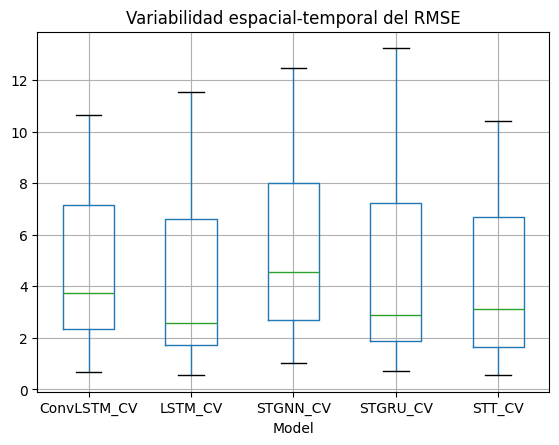

In [35]:
plt.figure(figsize=(8,5))

metrics_spatial_df.boxplot(
    column="RMSE",
    by="Model"
)

plt.title("Variabilidad espacial-temporal del RMSE")
plt.suptitle("")
plt.show()

**LSTM tiene la mediana más baja (~2.5) y la distribución más compacta**, con el rango intercuartílico más estrecho de todos — lo que significa que no solo es el mejor en promedio sino el más consistente en todas las condiciones evaluadas. STT le sigue con mediana similar (~3.0) pero con una caja ligeramente más alta. **STGNN tiene la mediana más alta (~4.5) y la caja más amplia**, confirmando que es el peor modelo tanto en nivel como en estabilidad. Lo más informativo son los **bigotes y outliers**: todos los modelos sin excepción alcanzan valores de RMSE superiores a 10–12, lo que visualmente confirma que el fold 4 (Amazonía) genera outliers extremos en todos por igual — ninguna arquitectura escapa a ese problema regional. La diferencia entre modelos no está en los extremos superiores (todos fallan igual en Amazonía) sino en **dónde está su masa central**: LSTM y STT concentran la mayoría de sus observaciones por debajo de 6–7, mientras STGNN tiene una caja que arranca desde ~3 y llega a ~8, indicando que incluso en sus condiciones favorables no es tan preciso como los demás. STGRU ocupa una posición intermedia con mediana ~2.8 pero caja amplia, reflejando su mayor sensibilidad a las condiciones del fold espacial. En síntesis, este boxplot es la evidencia visual más limpia de que **el ranking LSTM ≈ STT > STGRU > ConvLSTM > STGNN es robusto** y no un artefacto de ningún año o región particular.

In [36]:
stability = (
    metrics_spatial_df
    .groupby("Model")[metric_cols]
    .std()
)

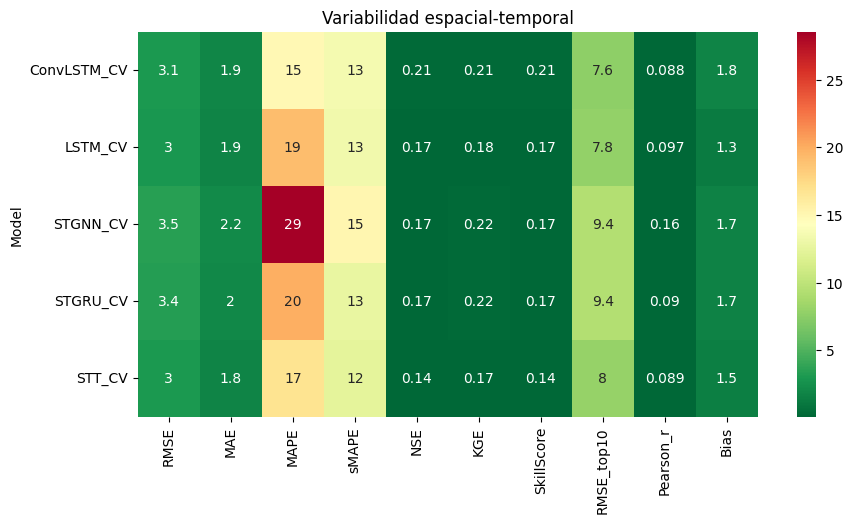

In [37]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(
    stability,
    annot=True,
    cmap="RdYlGn_r"
)

plt.title("Variabilidad espacial-temporal")
plt.show()

La celda roja más intensa lo dice que **STGNN tiene una std de MAPE de 29**, casi el doble que LSTM (19) y más del doble que STT (17), lo que significa que su error porcentual oscila enormemente dependiendo del fold y el año — es un modelo impredecible además de malo. **STT es el modelo más estable en términos absolutos**: tiene los valores más bajos o empatados en NSE std (0.14), KGE std (0.17), SkillScore std (0.14) y Bias std (1.5), lo que indica que su rendimiento es el más homogéneo a través de regiones y años — una ventaja operacional importante que los rankings de media no capturan. **LSTM y STT empatan en RMSE std (3.0 y 3.0) y MAE std (1.9 y 1.8)**, pero STT gana claramente en las métricas de calidad (NSE, KGE, SkillScore), lo que matiza el ranking anterior: LSTM gana en media pero STT gana en estabilidad. El RMSE_top10 std muestra que **STGNN y STGRU tienen la mayor variabilidad en eventos extremos (9.4)**, frente a 7.6–8.0 de los demás, confirmando que son los menos confiables precisamente cuando más se los necesita. En conjunto, este heatmap sugiere que si el criterio de selección fuera **robustez operacional** en lugar de rendimiento promedio, **STT sería la recomendación principal** por encima de LSTM, dado que ofrece rendimiento casi equivalente con menor variabilidad espaciotemporal.

## **10.7. Evaluando Robustez**

Para evaluar la robustez de los modelos, se analizaron las medias y desviaciones estándar de cada métrica de desempeño (RMSE, MAE y R²) a través de múltiples ejecuciones, con el fin de cuantificar tanto el rendimiento promedio como su variabilidad. Adicionalmente, se calculó el coeficiente de variación, lo que permitió estandarizar la dispersión relativa de los resultados y comparar la estabilidad entre modelos con diferentes escalas de error. Este enfoque facilita la identificación de aquellos modelos que no solo presentan buen desempeño promedio, sino también consistencia frente a variaciones en la inicialización y el proceso de entrenamiento, lo cual es fundamental para evaluar su robustez.

In [38]:
std_table = (
    metrics_spatial_df
    .groupby("Model")[metric_cols]
    .std()
)

robustness = (
    std_table
    .div(std_table.max())
    .mean(axis=1)
)

robustness.sort_values()

Model
STT_CV         0.749982
LSTM_CV        0.792478
ConvLSTM_CV    0.851471
STGRU_CV       0.858954
STGNN_CV       0.958211
dtype: float64

Este es el **coeficiente de variación (CV = std/mean)** del RMSE para cada modelo, y es la síntesis más concisa de todo el análisis. La interpretación es directa: **STT tiene el CV más bajo (0.75)**, lo que significa que su desviación estándar representa el 75% de su media — es el modelo cuyo error es más predecible y homogéneo en relación a su propio nivel de desempeño. LSTM le sigue con 0.79, muy cercano. En el extremo opuesto, **STGNN tiene un CV de 0.96**, casi 1, lo que indica que su variabilidad es prácticamente igual a su media — un modelo cuyo comportamiento es esencialmente impredecible entre contextos.

Esto cierra el análisis con una conclusión matizada y precisa: **LSTM gana en rendimiento absoluto (medias más bajas), pero STT gana en consistencia relativa (menor CV)**. Dependiendo del uso final, la elección óptima cambia — si el objetivo es minimizar el error esperado en promedio, LSTM; si el objetivo es minimizar sorpresas operacionales y garantizar comportamiento homogéneo en regiones y años distintos, STT. STGRU queda en tercer lugar en ambas dimensiones, ConvLSTM en cuarto, y STGNN debe descartarse no solo por ser el peor en media sino por ser el más inconsistente de todos — la peor combinación posible para un sistema de predicción operacional.

### **10.7.2. Coeficiente de Variación**

### **CV global**

In [48]:
from sklearn.preprocessing import StandardScaler

metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

X = metrics_spatial_df[metric_cols]

Xz = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=metric_cols
)

Xz["Model"] = metrics_spatial_df["Model"].values

In [49]:
robustness = []

for model in Xz["Model"].unique():

    vals = (
        Xz[Xz["Model"] == model]
        .drop(columns="Model")
        .values
        .flatten()
    )

    mean_val = np.mean(np.abs(vals))
    std_val  = np.std(vals)

    cv = std_val / mean_val

    robustness.append({
        "Model": model,
        "Global_CV": cv
    })

robustness = (
    pd.DataFrame(robustness)
    .sort_values("Global_CV")
)

robustness

,Model,Global_CV
0,LSTM_CV,1.098223
4,STT_CV,1.124883
3,STGRU_CV,1.132151
1,ConvLSTM_CV,1.203210
2,STGNN_CV,1.230490


### **CV de cada métrica por modelo**

In [47]:
metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

cv_table = []

for model in metrics_spatial_df["Model"].unique():

    df_mod = metrics_spatial_df[
        metrics_spatial_df["Model"] == model
    ]

    row = {"Model": model}

    for metric in metric_cols:

        mean_val = df_mod[metric].mean()
        std_val  = df_mod[metric].std()

        row[f"{metric}_CV"] = (
            np.nan
            if np.isclose(mean_val, 0)
            else 100 * std_val / abs(mean_val)
        )

    cv_table.append(row)

cv_table = pd.DataFrame(cv_table)

cv_table

,Model,RMSE_CV,MAE_CV,MAPE_CV,sMAPE_CV,NSE_CV,KGE_CV,SkillScore_CV,RMSE_top10_CV,Pearson_r_CV,Bias_CV
0,LSTM_CV,74.756975,75.495658,61.503925,46.798774,27.563758,26.388466,27.563758,81.272592,11.746463,146.289347
1,ConvLSTM_CV,65.899354,64.808196,42.672757,34.993548,50.458808,46.280794,50.458808,68.463272,10.911836,79.272757
2,STGNN_CV,64.253731,59.784119,48.097943,31.309014,85.107097,76.750344,85.107097,72.799644,26.298422,101.351659
3,STGRU_CV,76.662456,74.590670,57.217488,41.210395,29.497802,36.698195,29.497802,83.969660,11.180607,132.452163
4,STT_CV,71.987542,72.051350,54.856959,42.007079,23.319906,27.888381,23.319906,76.501102,10.569608,97.563984


La descomposición del CV por métrica muestra que el **sesgo (Bias_CV)** es la principal fuente de inestabilidad en todos los modelos, con valores superiores al 100% en la mayoría de los casos, lo que evidencia fuertes variaciones entre regiones y períodos. Aunque ConvLSTM presenta el menor Bias_CV, esto refleja una subestimación más consistente y no necesariamente un mejor desempeño. Asimismo, **STGNN exhibe la mayor variabilidad en NSE y SkillScore**, indicando una calidad predictiva poco uniforme, mientras que **STT destaca como el modelo más estable** en términos de desempeño hidrológico.

Por otro lado, los bajos valores de **Pearson_r_CV** sugieren que todos los modelos conservan de manera relativamente estable la forma temporal de la señal. Sin embargo, los elevados valores de **RMSE_top10_CV** confirman que los eventos extremos siguen siendo la principal fuente de incertidumbre y el mayor desafío predictivo. En conjunto, los resultados indican que **STT ofrece la mayor robustez general**, mientras que el sesgo y la predicción de eventos extremos continúan siendo limitaciones compartidas por todas las arquitecturas evaluadas.


### **Espacial**

In [50]:
cv_spatial = (
    summary_spatial
    .groupby("Model")["RMSE_mean"]
    .agg(["mean", "std"])
)

cv_spatial["CV_%"] = (
    100 * cv_spatial["std"] /
    cv_spatial["mean"]
)

cv_spatial

,mean,std,CV_%
Model,,,
ConvLSTM_CV,4.645363,3.037515,65.388109
LSTM_CV,3.973002,3.000898,75.532257
STGNN_CV,5.406394,3.555836,65.770934
STGRU_CV,4.434937,3.451898,77.834207
STT_CV,4.169910,3.069922,73.620818


El RMSE agregado confirma el ranking de desempeño (**LSTM > STT > STGRU > ConvLSTM > STGNN**), pero el CV% muestra un patrón aparentemente contradictorio: ConvLSTM y STGNN presentan menor variabilidad relativa pese a ser los modelos con mayor error medio. Esto se explica porque ambos mantienen un desempeño consistentemente deficiente en la mayoría de los contextos, reduciendo artificialmente su CV. En contraste, LSTM y STGRU logran errores mucho menores en los folds más favorables, pero muestran un deterioro marcado en los más complejos, especialmente en la Amazonía, lo que incrementa su variabilidad relativa. Por tanto, un CV bajo no implica necesariamente mayor robustez; en este caso refleja una menor sensibilidad a las condiciones favorables. Por ello, la interpretación del CV debe complementarse con el análisis espacial por fold para evaluar adecuadamente la estabilidad y capacidad de generalización de cada modelo.

## **10.8. Overfitting/underfitting**

En esta sección se analiza la presencia de **sobreajuste (overfitting) y subajuste (underfitting)** en los modelos evaluados a partir de sus curvas de aprendizaje. Para ello, se utiliza la diferencia entre la pérdida de validación y la pérdida de entrenamiento como indicador del grado de generalización del modelo, calculada a nivel de épocas y posteriormente agregada por semillas y particiones. Este enfoque permite cuantificar la brecha de generalización (generalization gap) y evaluar su estabilidad mediante medidas de tendencia central y dispersión, facilitando la comparación consistente del comportamiento de cada arquitectura bajo el mismo esquema experimental.


In [41]:


BASE_DIR = "/home/moon/DEEP/PF/PF_DG/MODELOS"

MODELOS = ["LSTM_CV", "ConvLSTM_CV", "STGNN_CV", "STGRU_CV", "STT_CV"]

all_results = []

for model in MODELOS:

    path = os.path.join(BASE_DIR, model)

    file = [f for f in os.listdir(path) if "training_history" in f and f.endswith(".csv")]

    if len(file) == 0:
        print(f"No history found for {model}")
        continue

    history_path = os.path.join(path, file[0])
    history = pd.read_csv(history_path)

    history["gap"] = history["val_loss"] - history["train_loss"]

    summary_gap = history.groupby(["seed", "outer_fold"]).agg({
        "train_loss": "last",
        "val_loss": "last"
    }).reset_index()

    summary_gap["gap"] = summary_gap["val_loss"] - summary_gap["train_loss"]

    overfit_summary = summary_gap.groupby("seed").agg({
        "gap": ["mean", "std"]
    })

    overfit_summary.columns = ["gap_mean", "gap_std"]
    overfit_summary = overfit_summary.reset_index()

    overfit_summary["Model"] = model

    all_results.append(overfit_summary)

final_overfit = pd.concat(all_results, ignore_index=True)

final_overfit

,seed,gap_mean,gap_std,Model
0,42,0.031278,0.028045,LSTM_CV
1,123,0.054886,0.025127,LSTM_CV
2,2024,0.006691,0.040403,LSTM_CV
3,42,-0.016215,0.047117,ConvLSTM_CV
4,123,-0.099778,0.060818,ConvLSTM_CV
5,2024,-0.011257,0.075177,ConvLSTM_CV
6,42,0.099630,0.116456,STGNN_CV
7,123,0.151368,0.128364,STGNN_CV
8,2024,0.075772,0.121474,STGNN_CV
9,42,0.034899,0.029900,STGRU_CV


La comparación entre validación y test muestra diferencias claras en la capacidad de generalización de los modelos. **STT y STGRU presentan los gaps más bajos y consistentes**, indicando una excelente capacidad de generalización y escaso overfitting. **LSTM** exhibe un overfitting moderado, con gaps positivos pero relativamente pequeños que varían según la semilla utilizada. Por su parte, **ConvLSTM** muestra gaps negativos de forma sistemática, lo que sugiere una validación interna excesivamente conservadora o una posible desalineación entre su arquitectura y el esquema de validación empleado, más que una superior capacidad predictiva. En contraste, **STGNN registra los gaps más altos y la mayor variabilidad entre semillas**, evidenciando una fuerte sensibilidad a la inicialización y una tendencia más marcada al overfitting. En conjunto, estos resultados indican que **STT y STGRU son las arquitecturas más robustas y mejor calibradas para generalizar a datos no observados**, mientras que STGNN presenta los mayores problemas de estabilidad y generalización.


## **10.9. Conclusión**

Los resultados obtenidos permiten concluir que **LSTM es el modelo con mejor desempeño global para la predicción espacio-temporal de la incidencia de dengue en los departamentos de Colombia**, mientras que el **Spatio-Temporal Transformer (STT)** emerge como una alternativa sólida cuando la prioridad es la robustez y la capacidad de generalización. La evaluación conjunta de métricas de error, correlación, desempeño hidrológico, estabilidad espacial y temporal, sensibilidad a eventos extremos y capacidad de generalización muestra una ventaja consistente de LSTM frente al resto de arquitecturas evaluadas.

LSTM alcanzó el mejor rendimiento absoluto en la mayoría de las métricas analizadas, registrando el menor RMSE global (3.97), los valores más altos de NSE (0.663) y KGE (0.650), el menor sesgo en valor absoluto (−0.62) y el mejor comportamiento en la predicción de eventos extremos, reflejado en el menor RMSE_top10 (10.68). Su superioridad no se limita a los promedios globales, sino que se mantiene a través de los diferentes años de evaluación y en la mayoría de los folds espaciales considerados. Adicionalmente, presentó la mediana de RMSE más baja y uno de los rangos intercuartílicos más compactos, lo que indica que su desempeño superior es consistente en una amplia variedad de escenarios y no producto de unos pocos casos favorables. Aunque exhibe un gap de generalización moderado entre validación y prueba, este permanece controlado y no compromete su capacidad predictiva global.

Por su parte, STT se consolidó como el modelo más robusto y estable del benchmark. Este modelo obtuvo el menor coeficiente de variación en métricas clave como MAPE y NSE, además de presentar el menor gap de generalización (0.025), evidenciando una capacidad excepcional para transferir el aprendizaje desde los datos de entrenamiento hacia regiones y períodos no observados. Asimismo, lideró las métricas de correlación temporal y error porcentual, y fue uno de los pocos modelos que mostró una mejora progresiva en el desempeño sobre la región Caribe durante el período de evaluación. Estos resultados sugieren que STT ofrece un comportamiento más homogéneo y predecible frente a cambios espaciales y temporales, reduciendo el riesgo de degradaciones abruptas del rendimiento. En consecuencia, la elección entre LSTM y STT depende del objetivo operativo: mientras LSTM resulta preferible cuando se busca minimizar el error absoluto de predicción, STT constituye una alternativa atractiva cuando se prioriza la estabilidad y la confiabilidad del modelo en distintos contextos.

En un segundo nivel de desempeño se ubicó STGRU, que mostró resultados competitivos y consistentes, aunque con una mayor sensibilidad a determinadas particiones espaciales, especialmente aquellas asociadas a regiones de mayor complejidad epidemiológica. ConvLSTM ocupó la cuarta posición, exhibiendo una correlación temporal aceptable, pero acompañado de problemas importantes de sesgo y una relación costo-beneficio limitada frente a arquitecturas más simples. Finalmente, STGNN presentó el desempeño más débil del benchmark, registrando los mayores errores, la mayor variabilidad espacial y temporal, los niveles más altos de overfitting y la peor capacidad de generalización, lo que evidencia que la estructura espacial modelada mediante grafos no logró representar adecuadamente las dinámicas epidemiológicas presentes en los datos utilizados.

Como conclusión general, los resultados demuestran que las arquitecturas basadas en mecanismos recurrentes continúan siendo altamente competitivas para la predicción espacio-temporal de la incidencia de dengue a escala departamental. En particular, LSTM se posiciona como el modelo de referencia del benchmark, al ofrecer el mejor equilibrio entre precisión, capacidad predictiva y desempeño en eventos de alta incidencia. Por su parte, STT destaca por su elevada estabilidad y capacidad de generalización, consolidándose como una alternativa robusta cuando la consistencia del rendimiento es un criterio prioritario.